In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# ============================================================
# NIFTY 50 (2014–2024)
# COMPLETE EXPLORATORY DATA ANALYSIS AND STATISTICAL ANALYSIS
# Daily, Monthly and Yearly Data
# ============================================================


# ============================================================
# IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    shapiro,
    normaltest,
    jarque_bera,
    f
)

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.tsa.stattools import adfuller, kpss


# Plot settings
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


print("All libraries imported successfully.")

All libraries imported successfully.


In [19]:

# ============================================================
# FILE PATHS
# ============================================================

# Check whether the notebook is running in Google Colab
if os.path.exists('/content/drive/MyDrive/research/Nifty 50 Historical Data (2014-2024) Daily.csv'):

    # Google Colab path
    daily_path = "/content/drive/MyDrive/research/Nifty 50 Historical Data (2014-2024) Daily.csv"
    monthly_path = "/content/drive/MyDrive/research/Nifty 50 Historical Data (2014-2024) Monthly.csv"
    yearly_path = "/content/drive/MyDrive/research/Yearly Data.csv"

else:

    # GitHub / local path
    daily_path = "Nifty 50 Historical Data (2014-2024) Daily.csv"
    monthly_path = "Nifty 50 Historical Data (2014-2024) Monthly.csv"
    yearly_path = "Yearly Data.csv"


print("Daily file exists:", os.path.exists(daily_path))
print("Monthly file exists:", os.path.exists(monthly_path))
print("Yearly file exists:", os.path.exists(yearly_path))

Daily file exists: True
Monthly file exists: True
Yearly file exists: True


In [20]:
# ============================================================
# LOAD DATASETS
# ============================================================

daily_raw = pd.read_csv(daily_path)
monthly_raw = pd.read_csv(monthly_path)
yearly_raw = pd.read_csv(yearly_path)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [21]:
# ============================================================
# BASIC DATASET INFORMATION
# ============================================================

datasets_raw = {
    "Daily": daily_raw,
    "Monthly": monthly_raw,
    "Yearly": yearly_raw
}


for name, df in datasets_raw.items():

    print("\n" + "=" * 80)
    print(f"{name.upper()} DATA")
    print("=" * 80)

    print("\nShape:", df.shape)

    print("\nFirst 5 observations:")
    print(df.head())

    print("\nLast 5 observations:")
    print(df.tail())

    print("\nData types:")
    print(df.dtypes)

    print("\nDescriptive statistics:")
    print(df.describe(include="all"))


DAILY DATA

Shape: (2698, 6)

First 5 observations:
         Date     Price      Open      High       Low         Vol.
0  27-11-2024  24278.20  24235.40  24353.60  24146.60  295010000.0
1  26-11-2024  24194.50  24343.30  24343.30  24125.40  230690000.0
2  25-11-2024  24221.90  24253.55  24351.55  24135.45  687170000.0
3  22-11-2024  23907.25  23411.80  23956.10  23359.00  367560000.0
4  21-11-2024  23349.90  23488.45  23507.30  23263.15  420330000.0

Last 5 observations:
            Date    Price     Open    High      Low         Vol.
2693  07-01-2014  6162.25  6203.90  6221.5  6144.75  138560000.0
2694  06-01-2014  6191.45  6220.85  6224.7  6170.25  118350000.0
2695  03-01-2014  6211.15  6194.55  6221.7  6171.25  139040000.0
2696  02-01-2014  6221.15  6301.25  6358.3  6211.30  158130000.0
2697  01-01-2014  6301.65  6323.80  6327.2  6298.25   69570000.0

Data types:
Date      object
Price    float64
Open     float64
High     float64
Low      float64
Vol.     float64
dtype: object

Des

In [22]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)


missing_results = []

for name, df in datasets_raw.items():

    for col in df.columns:

        missing_results.append({
            "Dataset": name,
            "Variable": col,
            "Missing Values": df[col].isna().sum(),
            "Missing Percentage": (
                df[col].isna().sum() / len(df)
            ) * 100
        })


missing_table = pd.DataFrame(missing_results)

print(missing_table)


MISSING VALUE ANALYSIS
    Dataset Variable  Missing Values  Missing Percentage
0     Daily     Date               0            0.000000
1     Daily    Price               0            0.000000
2     Daily     Open               0            0.000000
3     Daily     High               0            0.000000
4     Daily      Low               0            0.000000
5     Daily     Vol.               4            0.148258
6   Monthly     Date               0            0.000000
7   Monthly    Price               0            0.000000
8   Monthly     Open               0            0.000000
9   Monthly     High               0            0.000000
10  Monthly      Low               0            0.000000
11  Monthly     Vol.               0            0.000000
12   Yearly     Date               0            0.000000
13   Yearly    Price               0            0.000000
14   Yearly     Open               0            0.000000
15   Yearly     High               0            0.000000
16   Ye

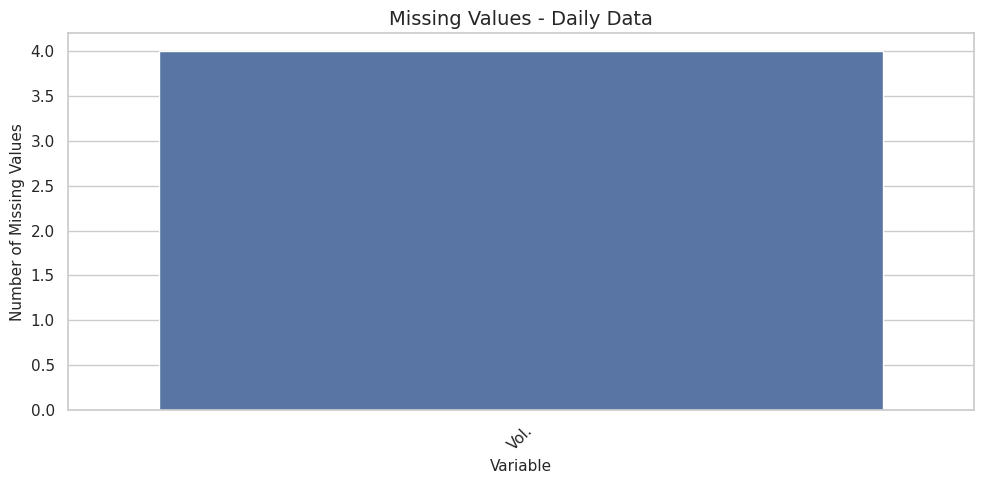

No missing values found in Monthly dataset.
No missing values found in Yearly dataset.


In [23]:
# ============================================================
# MISSING VALUE VISUALIZATION
# ============================================================

for name, df in datasets_raw.items():

    missing = df.isna().sum()

    missing = missing[missing > 0]

    if len(missing) > 0:

        plt.figure(figsize=(10, 5))

        sns.barplot(
            x=missing.index,
            y=missing.values
        )

        plt.title(f"Missing Values - {name} Data")
        plt.xlabel("Variable")
        plt.ylabel("Number of Missing Values")

        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

    else:

        print(f"No missing values found in {name} dataset.")

In [24]:
# ============================================================
# DATA PREPROCESSING
# ============================================================

def preprocess_data(df, volume_scale):

    df = df.copy()

    # --------------------------------------------------------
    # Date conversion
    # --------------------------------------------------------

    if "Date" in df.columns:

        df["Date"] = pd.to_datetime(
            df["Date"],
            errors="coerce",
            dayfirst=True
        )

    # --------------------------------------------------------
    # Volume missing values
    # --------------------------------------------------------

    if "Vol." in df.columns:

        df["Vol."] = df["Vol."].fillna(
            df["Vol."].median()
        )

        # Scaled volume
        df["vol."] = df["Vol."] / volume_scale

        # Remove original volume
        df.drop(
            columns=["Vol."],
            inplace=True
        )

    # --------------------------------------------------------
    # Sort chronologically
    # --------------------------------------------------------

    if "Date" in df.columns:

        df = df.sort_values("Date")
        df = df.reset_index(drop=True)

    return df


daily = preprocess_data(
    daily_raw,
    volume_scale=10000
)

monthly = preprocess_data(
    monthly_raw,
    volume_scale=1000000
)

yearly = preprocess_data(
    yearly_raw,
    volume_scale=1000000
)


datasets = {
    "Daily": daily,
    "Monthly": monthly,
    "Yearly": yearly
}


print("\nPreprocessing completed.")


Preprocessing completed.


In [25]:
# ============================================================
# CHECK DATA AFTER PREPROCESSING
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 80)
    print(f"{name.upper()} DATA AFTER PREPROCESSING")
    print("=" * 80)

    print("Shape:", df.shape)

    print("\nMissing values:")
    print(df.isna().sum())

    print("\nData types:")
    print(df.dtypes)



DAILY DATA AFTER PREPROCESSING
Shape: (2698, 6)

Missing values:
Date     0
Price    0
Open     0
High     0
Low      0
vol.     0
dtype: int64

Data types:
Date     datetime64[ns]
Price           float64
Open            float64
High            float64
Low             float64
vol.            float64
dtype: object

MONTHLY DATA AFTER PREPROCESSING
Shape: (131, 6)

Missing values:
Date     0
Price    0
Open     0
High     0
Low      0
vol.     0
dtype: int64

Data types:
Date     datetime64[ns]
Price           float64
Open            float64
High            float64
Low             float64
vol.            float64
dtype: object

YEARLY DATA AFTER PREPROCESSING
Shape: (11, 6)

Missing values:
Date     0
Price    0
Open     0
High     0
Low      0
vol.     0
dtype: int64

Data types:
Date     datetime64[ns]
Price           float64
Open            float64
High            float64
Low             float64
vol.            float64
dtype: object


In [26]:
# ============================================================
# NUMERICAL VARIABLES
# ============================================================

for name, df in datasets.items():

    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns.tolist()

    print(f"\n{name} numerical variables:")
    print(numeric_columns)


Daily numerical variables:
['Price', 'Open', 'High', 'Low', 'vol.']

Monthly numerical variables:
['Price', 'Open', 'High', 'Low', 'vol.']

Yearly numerical variables:
['Price', 'Open', 'High', 'Low', 'vol.']


In [27]:
# ============================================================
# OUTLIER DETECTION USING IQR
# ============================================================

def outlier_summary(df):

    numeric_df = df.select_dtypes(
        include=np.number
    )

    Q1 = numeric_df.quantile(0.25)
    Q3 = numeric_df.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (numeric_df < lower_bound) |
        (numeric_df > upper_bound)
    )

    summary = pd.DataFrame({
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_mask.sum(),
        "Outlier Percentage": (
            outlier_mask.sum() / len(df)
        ) * 100
    })

    return summary


outlier_results = {}

for name, df in datasets.items():

    result = outlier_summary(df)

    outlier_results[name] = result

    print("\n" + "=" * 80)
    print(f"OUTLIER ANALYSIS - {name.upper()} DATA")
    print("=" * 80)

    print(result.round(4))


OUTLIER ANALYSIS - DAILY DATA
               Q1          Q3         IQR  Lower Bound  Upper Bound  \
Price   8632.6375  17183.4500   8550.8125   -4193.5812   30009.6688   
Open    8635.2875  17189.2875   8554.0000   -4195.7125   30020.2875   
High    8675.5875  17297.3375   8621.7500   -4257.0375   30229.9625   
Low     8577.8625  17064.6375   8486.7750   -4152.3000   29794.8000   
vol.   18704.0000  37298.0000  18594.0000   -9187.0000   65189.0000   

       Outlier Count  Outlier Percentage  
Price              0              0.0000  
Open               0              0.0000  
High               0              0.0000  
Low                0              0.0000  
vol.             180              6.6716  

OUTLIER ANALYSIS - MONTHLY DATA
             Q1         Q3       IQR  Lower Bound  Upper Bound  Outlier Count  \
Price  8618.425  17145.225  8526.800   -4171.7750   29935.4250              0   
Open   8629.125  17145.000  8515.875   -4144.6875   29918.8125              0   
High   8

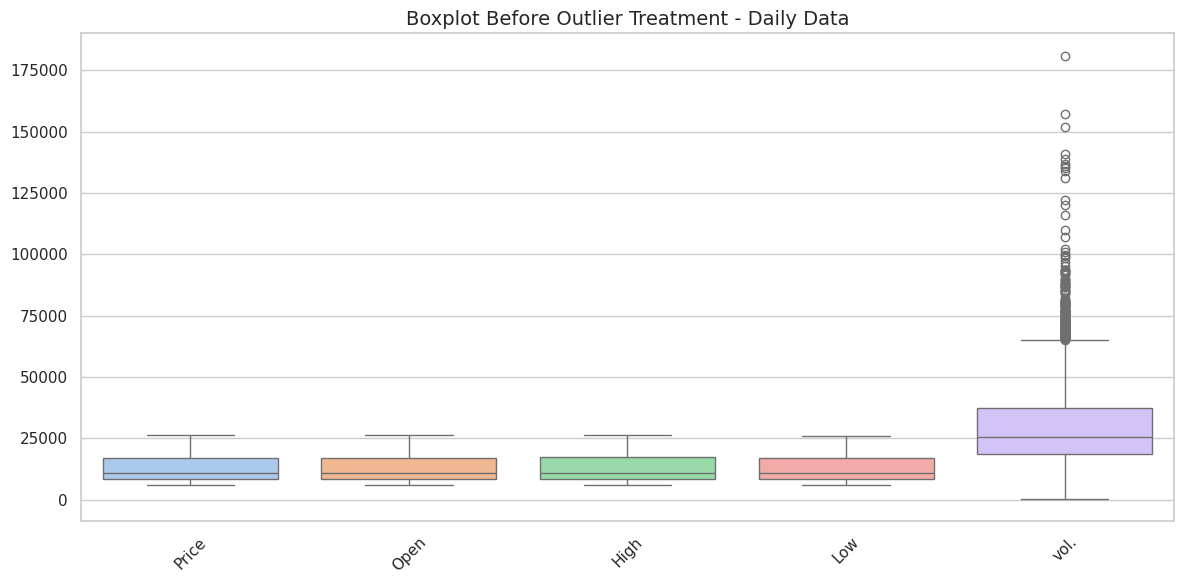

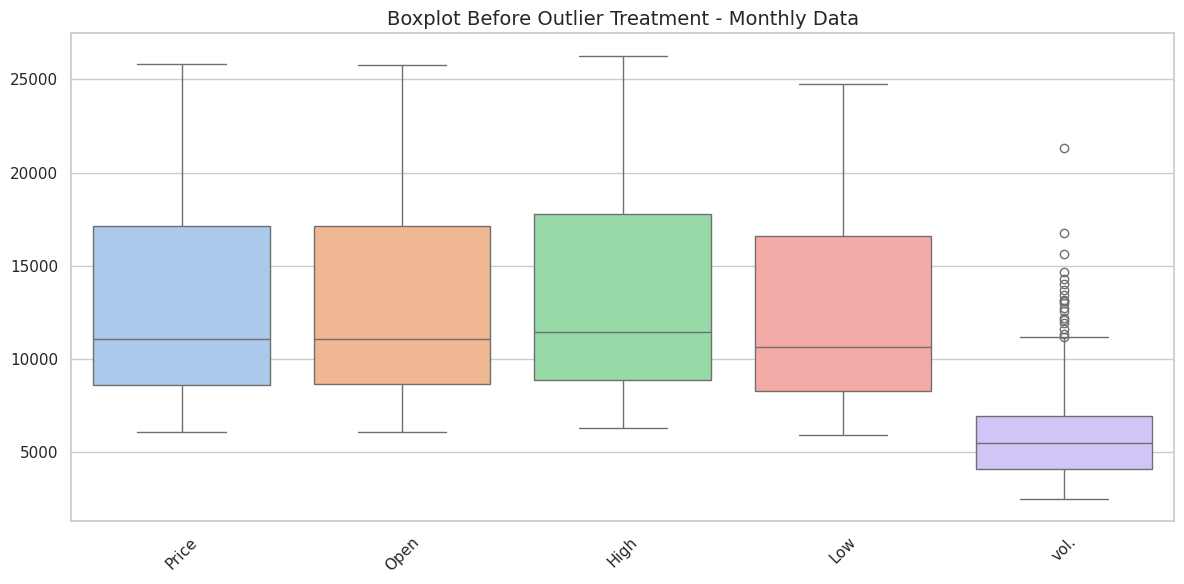

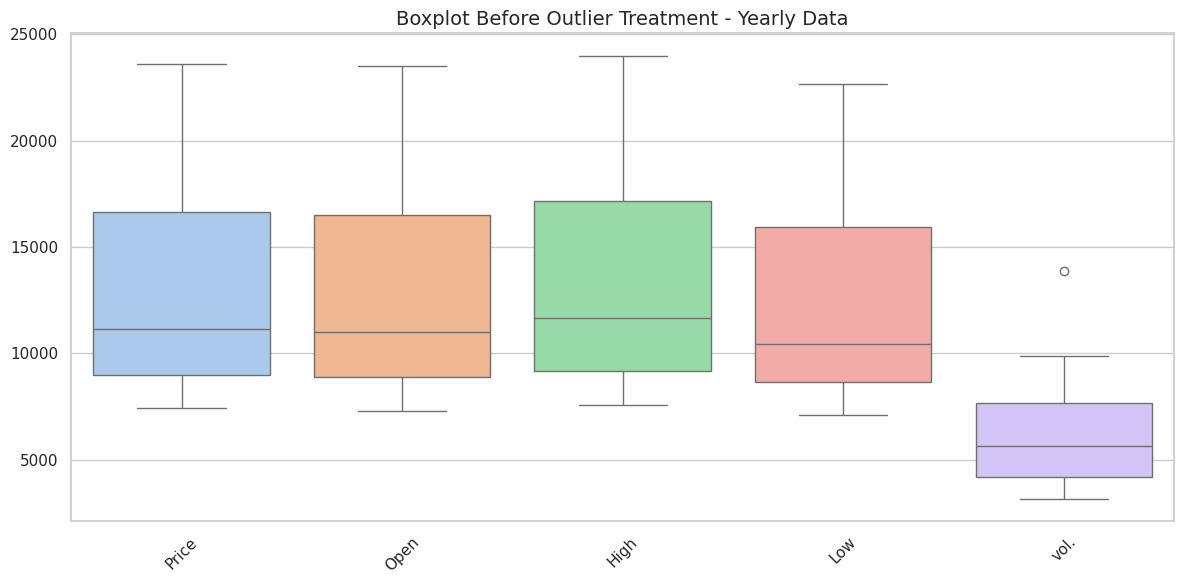

In [28]:
# ============================================================
# BOXPLOTS BEFORE OUTLIER TREATMENT
# ============================================================

for name, df in datasets.items():

    numeric_df = df.select_dtypes(
        include=np.number
    )

    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=numeric_df,
        palette="pastel"
    )

    plt.title(
        f"Boxplot Before Outlier Treatment - {name} Data"
    )

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [29]:
# ============================================================
# CREATE CLEAN DATASETS
# ============================================================
#
# IMPORTANT:
# Financial market extremes may represent genuine market events.
# Therefore, the original datasets are preserved.
#
# The following function creates IQR-cleaned versions for
# sensitivity analysis.
# ============================================================

def remove_outliers_iqr(df):

    numeric_df = df.select_dtypes(
        include=np.number
    )

    Q1 = numeric_df.quantile(0.25)
    Q3 = numeric_df.quantile(0.75)

    IQR = Q3 - Q1

    mask = ~(
        (numeric_df < (Q1 - 1.5 * IQR)) |
        (numeric_df > (Q3 + 1.5 * IQR))
    ).any(axis=1)

    return df.loc[mask].copy()


daily_clean = remove_outliers_iqr(daily)
monthly_clean = remove_outliers_iqr(monthly)
yearly_clean = remove_outliers_iqr(yearly)


clean_datasets = {
    "Daily": daily_clean,
    "Monthly": monthly_clean,
    "Yearly": yearly_clean
}

In [30]:
# ============================================================
# OBSERVATIONS BEFORE AND AFTER OUTLIER TREATMENT
# ============================================================

outlier_comparison = pd.DataFrame({

    "Dataset": ["Daily", "Monthly", "Yearly"],

    "Original Observations": [
        len(daily),
        len(monthly),
        len(yearly)
    ],

    "After IQR Treatment": [
        len(daily_clean),
        len(monthly_clean),
        len(yearly_clean)
    ]
})


outlier_comparison["Observations Removed"] = (
    outlier_comparison["Original Observations"]
    -
    outlier_comparison["After IQR Treatment"]
)


outlier_comparison["Percentage Removed"] = (
    outlier_comparison["Observations Removed"]
    /
    outlier_comparison["Original Observations"]
) * 100


print("\n")
print(outlier_comparison.round(4))



   Dataset  Original Observations  After IQR Treatment  Observations Removed  \
0    Daily                   2698                 2518                   180   
1  Monthly                    131                  112                    19   
2   Yearly                     11                   10                     1   

   Percentage Removed  
0              6.6716  
1             14.5038  
2              9.0909  


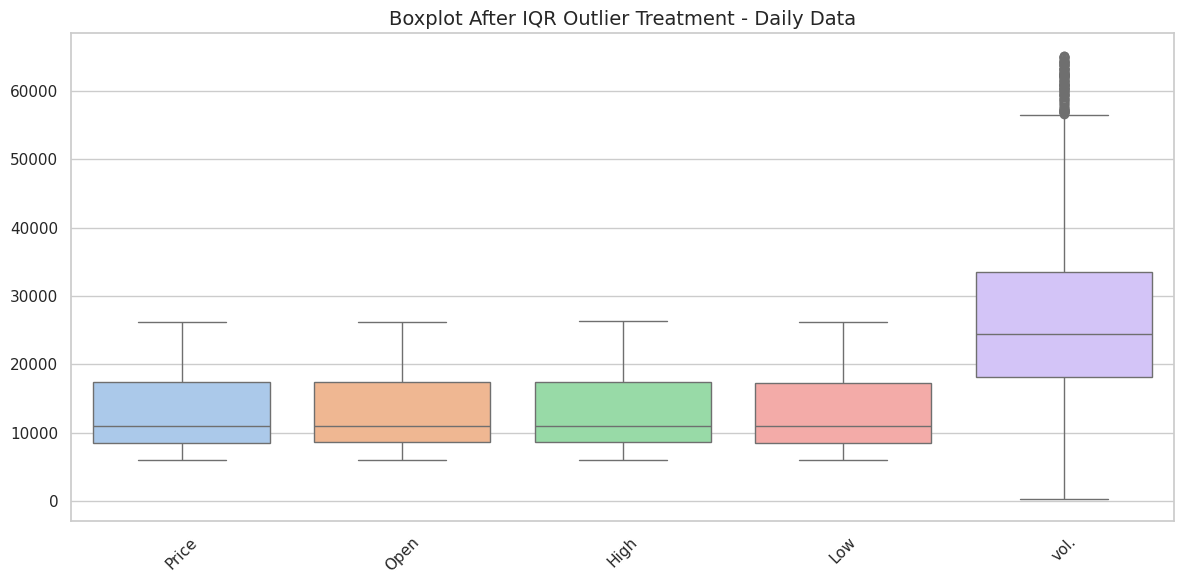

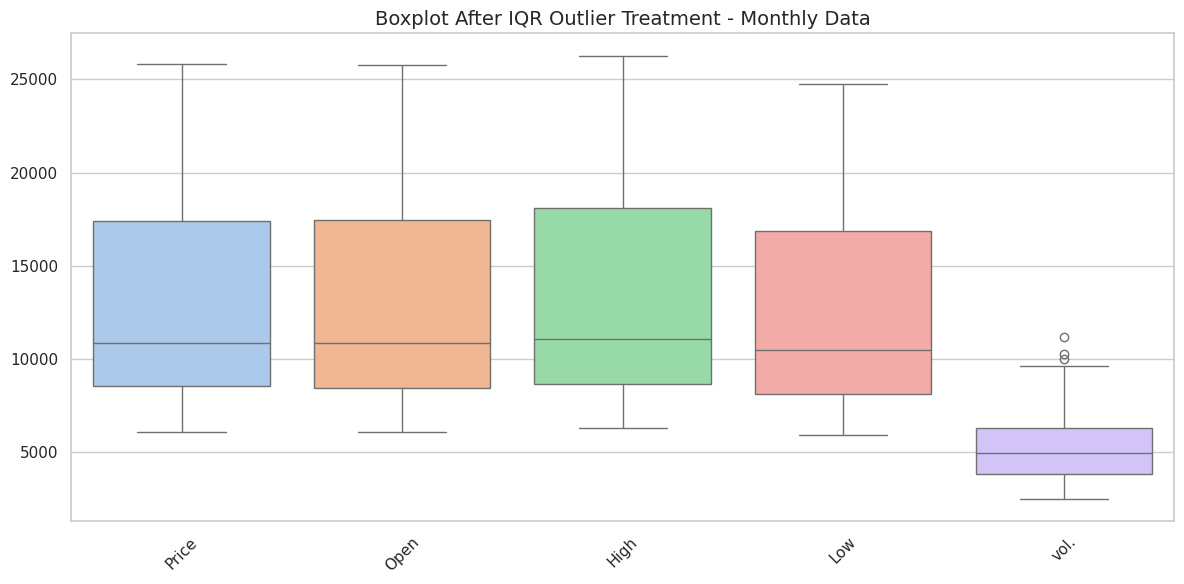

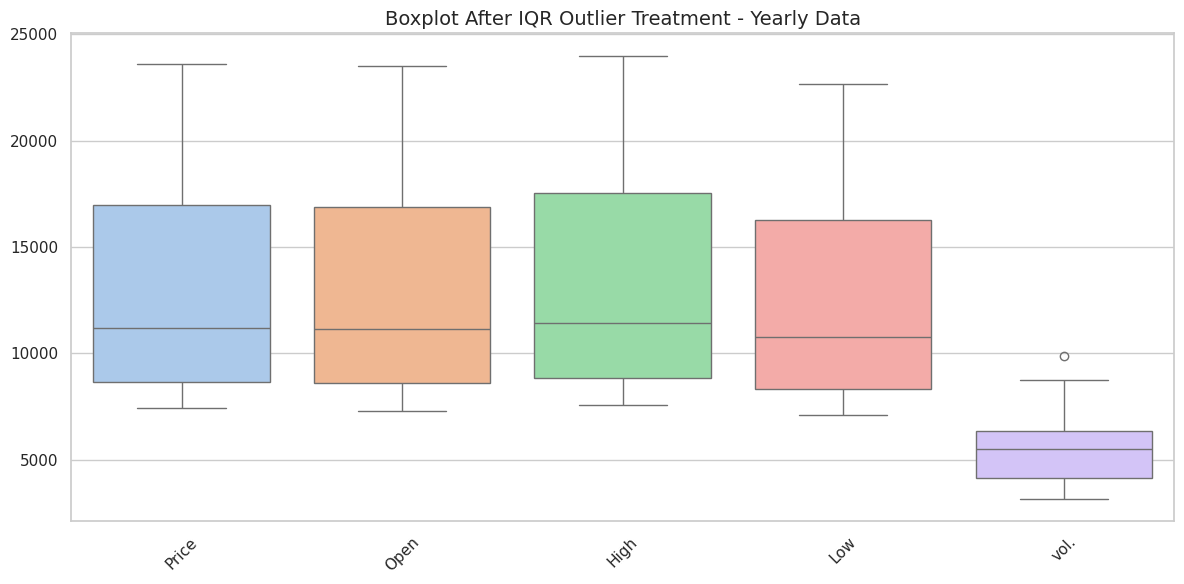

In [31]:
# ============================================================
# BOXPLOTS AFTER OUTLIER TREATMENT
# ============================================================

for name, df in clean_datasets.items():

    numeric_df = df.select_dtypes(
        include=np.number
    )

    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=numeric_df,
        palette="pastel"
    )

    plt.title(
        f"Boxplot After IQR Outlier Treatment - {name} Data"
    )

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [32]:
# ============================================================
# CREATE WORKING COPIES
# ============================================================

daily = daily_raw.copy()
monthly = monthly_raw.copy()
yearly = yearly_raw.copy()

In [33]:
# ============================================================
# DETAILED DESCRIPTIVE STATISTICS
# ============================================================

def descriptive_statistics(df):

    numeric_df = df.select_dtypes(
        include=np.number
    )

    result = pd.DataFrame({

        "Count": numeric_df.count(),

        "Mean": numeric_df.mean(),

        "Median": numeric_df.median(),

        "Standard Deviation": numeric_df.std(),

        "Variance": numeric_df.var(),

        "Minimum": numeric_df.min(),

        "Maximum": numeric_df.max(),

        "Range": (
            numeric_df.max()
            -
            numeric_df.min()
        ),

        "Q1": numeric_df.quantile(0.25),

        "Q3": numeric_df.quantile(0.75),

        "IQR": (
            numeric_df.quantile(0.75)
            -
            numeric_df.quantile(0.25)
        ),

        "Skewness": numeric_df.skew(),

        "Kurtosis": numeric_df.kurtosis()
    })

    return result


descriptive_results = {}

for name, df in clean_datasets.items():

    result = descriptive_statistics(df)

    descriptive_results[name] = result

    print("\n" + "=" * 80)
    print(f"DETAILED DESCRIPTIVE STATISTICS - {name.upper()}")
    print("=" * 80)

    print(result.round(4))


DETAILED DESCRIPTIVE STATISTICS - DAILY
       Count        Mean     Median  Standard Deviation      Variance  \
Price   2518  12947.8935  11000.200           5095.2147  2.596121e+07   
Open    2518  12955.9396  10996.725           5095.7926  2.596710e+07   
High    2518  13012.1083  11050.850           5116.5840  2.617943e+07   
Low     2518  12880.1750  10923.650           5070.7815  2.571282e+07   
vol.    2518  27735.1668  24492.000          12982.5357  1.685462e+08   

       Minimum   Maximum     Range          Q1          Q3         IQR  \
Price   6000.9  26216.05  20215.15   8552.3000  17358.6375   8806.3375   
Open    5947.6  26248.25  20300.65   8570.9625  17382.2500   8811.2875   
High    6017.8  26277.35  20259.55   8605.7375  17441.9125   8836.1750   
Low     5933.3  26151.40  20218.10   8516.7125  17254.9500   8738.2375   
vol.     283.0  65172.00  64889.00  18098.7500  33477.0000  15378.2500   

       Skewness  Kurtosis  
Price    0.7302   -0.6131  
Open     0.7296   -

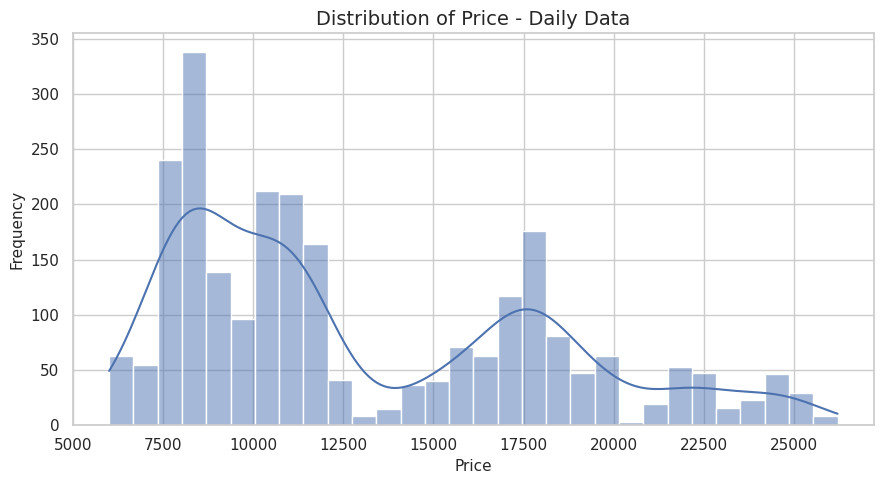

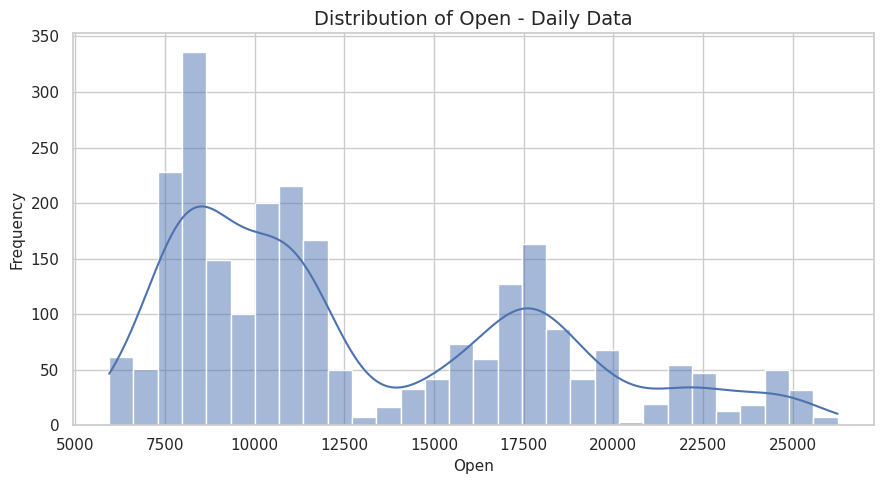

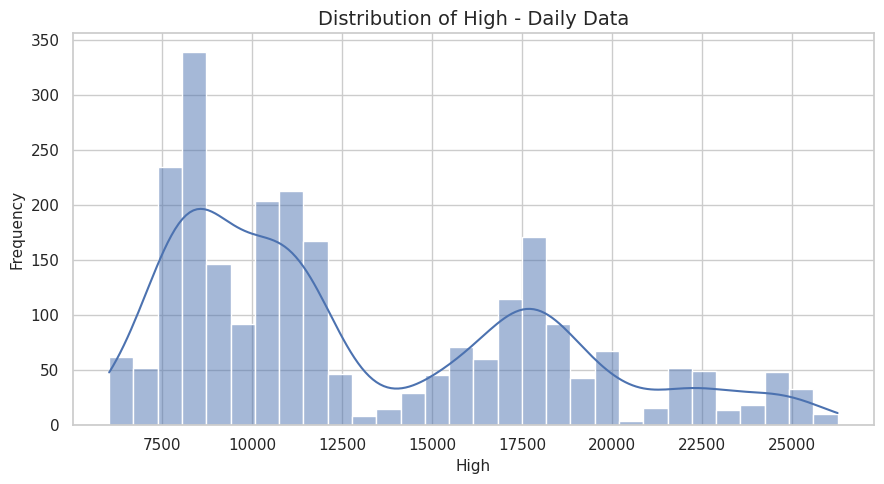

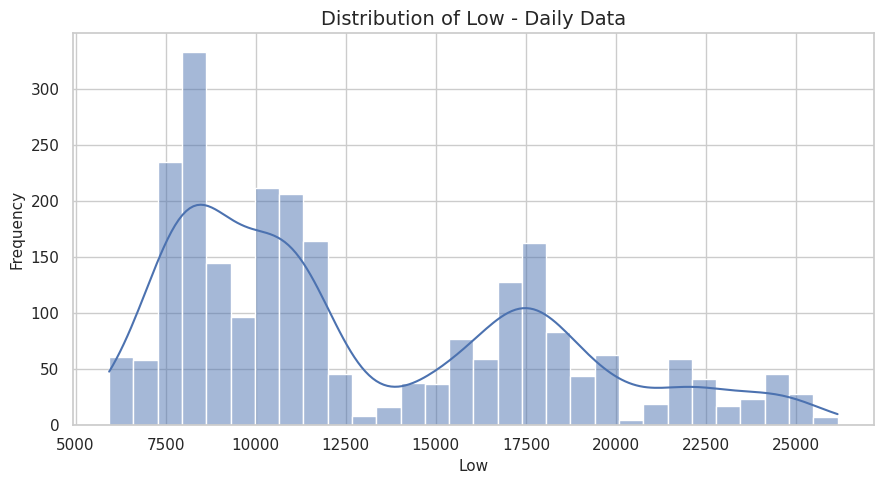

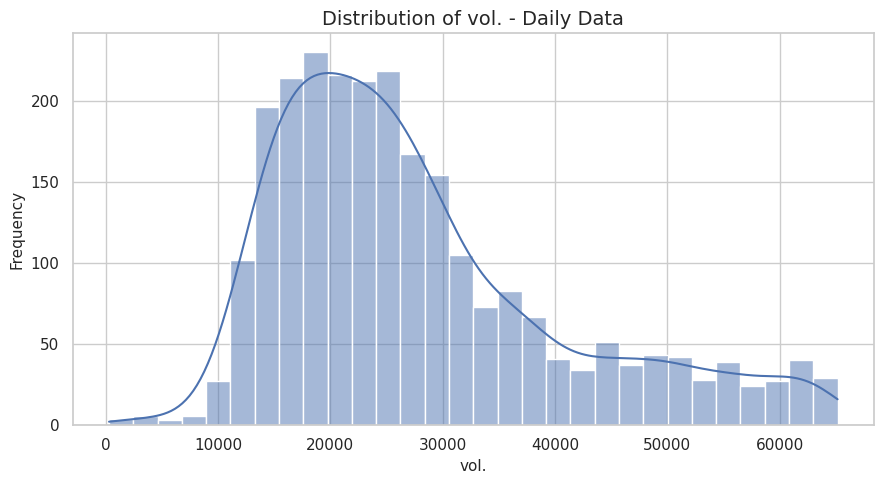

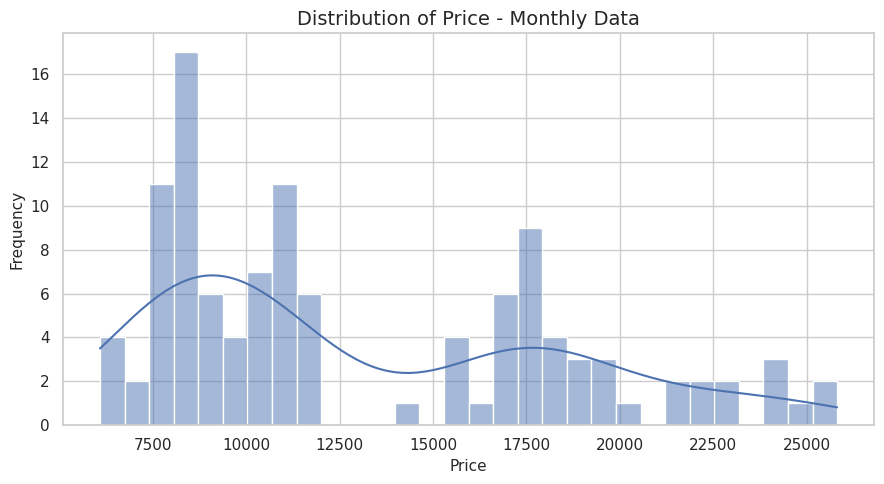

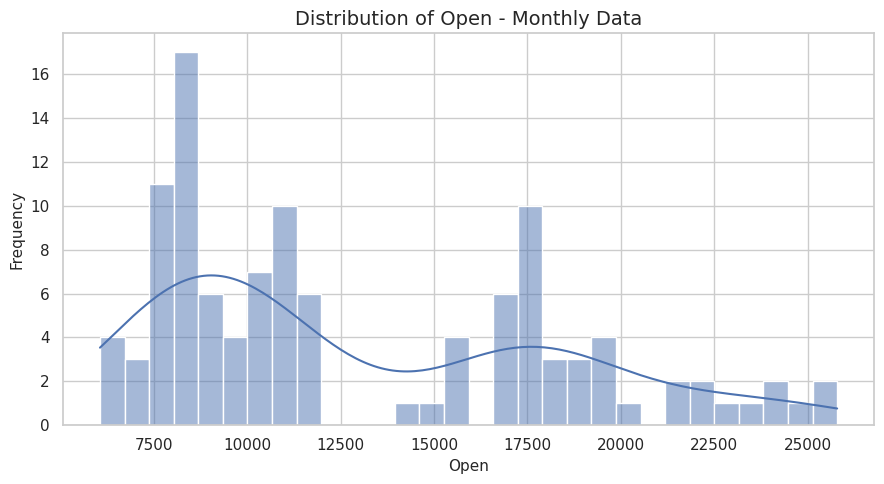

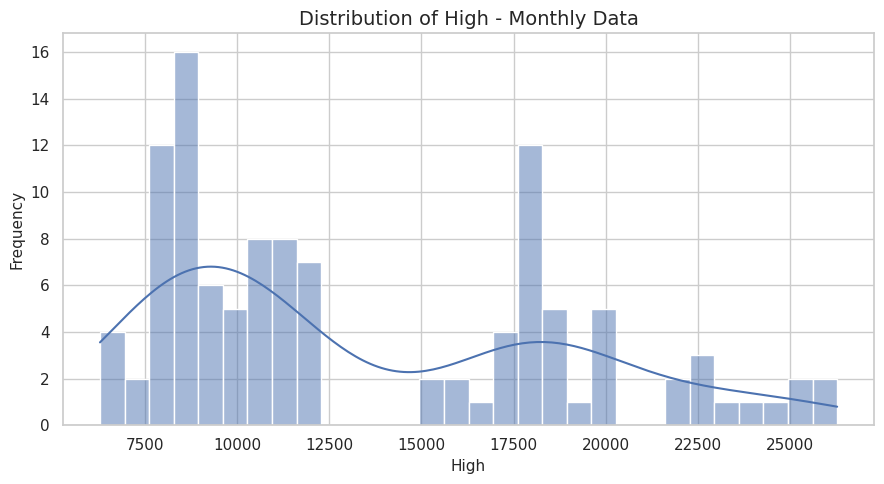

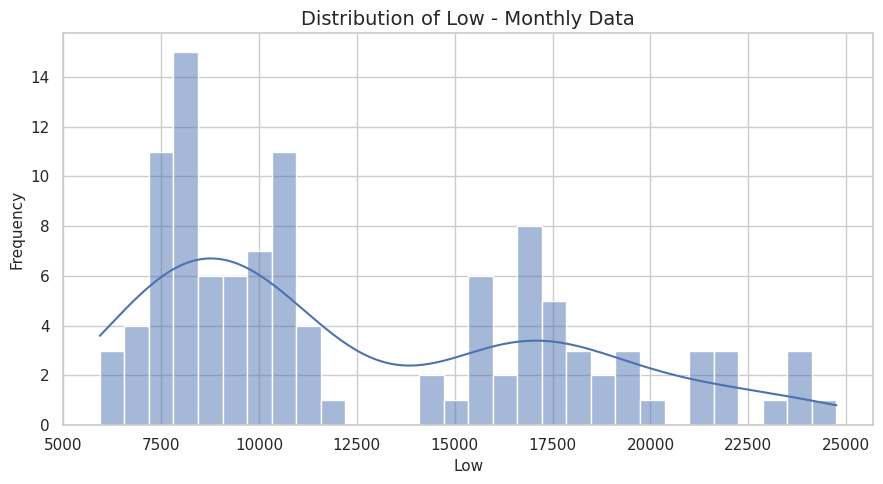

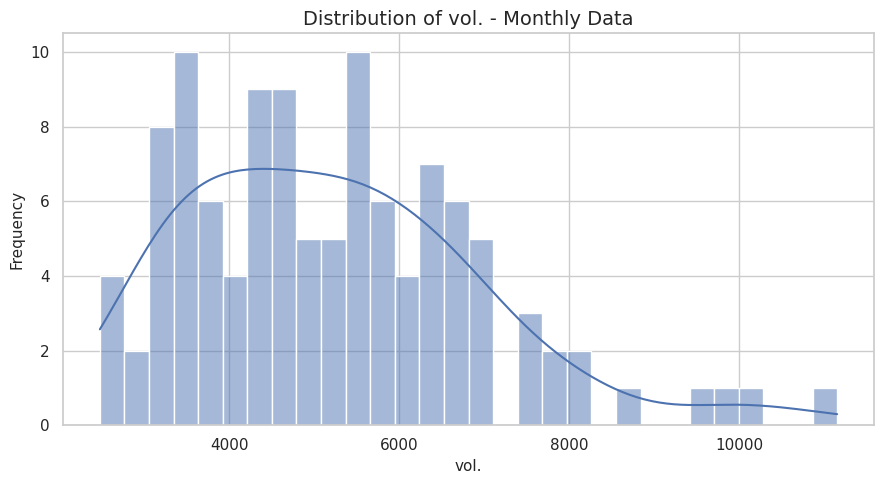

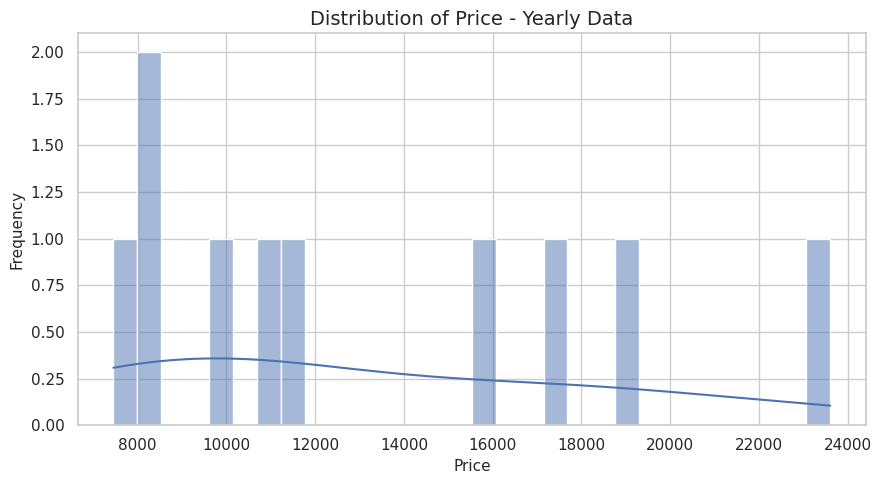

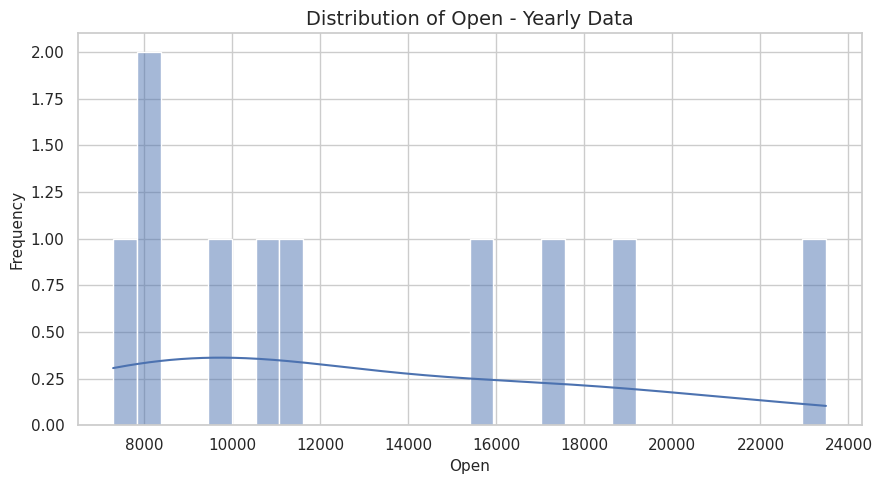

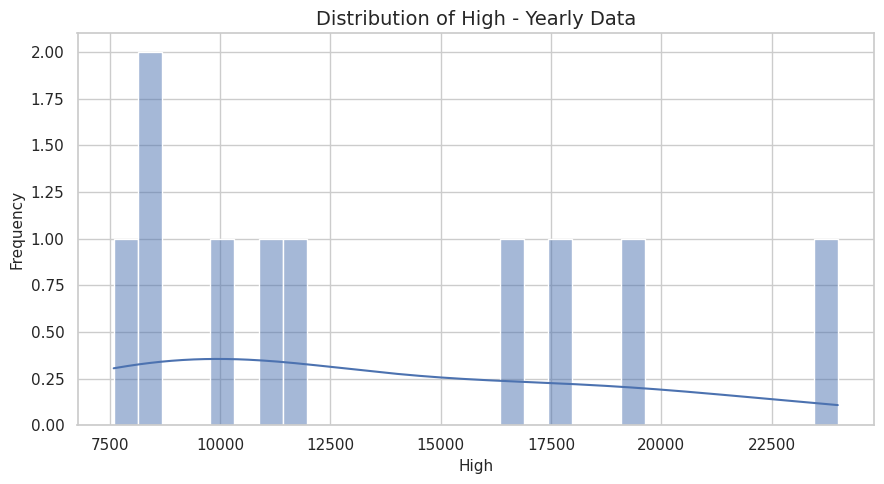

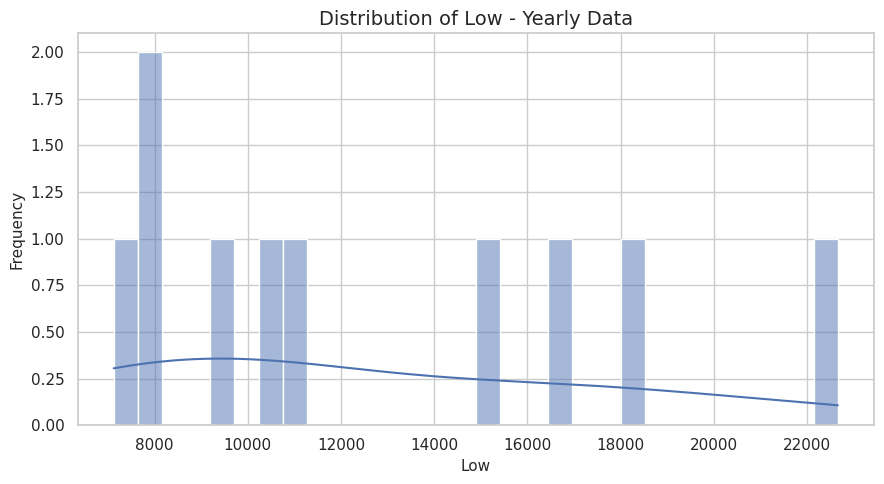

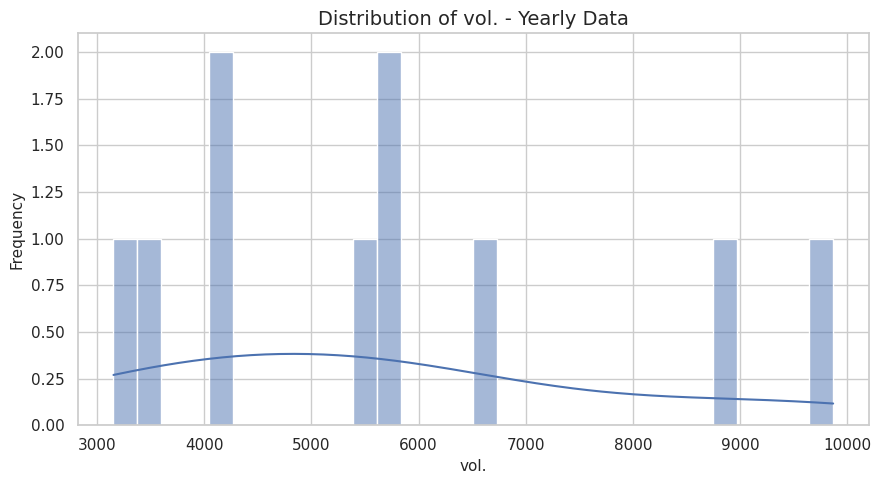

In [34]:
# ============================================================
# DISTRIBUTION ANALYSIS
# ============================================================

for name, df in clean_datasets.items():

    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns

    for col in numeric_columns:

        plt.figure(figsize=(9, 5))

        sns.histplot(
            df[col].dropna(),
            bins=30,
            kde=True
        )

        plt.title(
            f"Distribution of {col} - {name} Data"
        )

        plt.xlabel(col)
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

In [35]:
# ============================================================
# SKEWNESS AND KURTOSIS
# ============================================================

for name, result in descriptive_results.items():

    print("\n" + "=" * 80)
    print(f"SKEWNESS AND KURTOSIS - {name.upper()}")
    print("=" * 80)

    print(
        result[
            ["Skewness", "Kurtosis"]
        ].round(4)
    )


SKEWNESS AND KURTOSIS - DAILY
       Skewness  Kurtosis
Price    0.7302   -0.6131
Open     0.7296   -0.6129
High     0.7297   -0.6141
Low      0.7321   -0.6071
vol.     1.0521    0.4742

SKEWNESS AND KURTOSIS - MONTHLY
       Skewness  Kurtosis
Price    0.6931   -0.7667
Open     0.6957   -0.7260
High     0.6744   -0.8143
Low      0.6792   -0.7966
vol.     0.8866    0.9506

SKEWNESS AND KURTOSIS - YEARLY
       Skewness  Kurtosis
Price    0.7868   -0.5043
Open     0.7992   -0.4382
High     0.7542   -0.6239
Low      0.7751   -0.5400
vol.     0.8806    0.0154



CORRELATION MATRIX - DAILY
        Price    Open    High     Low    vol.
Price  1.0000  0.9998  0.9999  0.9999  0.2810
Open   0.9998  1.0000  0.9999  0.9999  0.2815
High   0.9999  0.9999  1.0000  0.9999  0.2829
Low    0.9999  0.9999  0.9999  1.0000  0.2790
vol.   0.2810  0.2815  0.2829  0.2790  1.0000


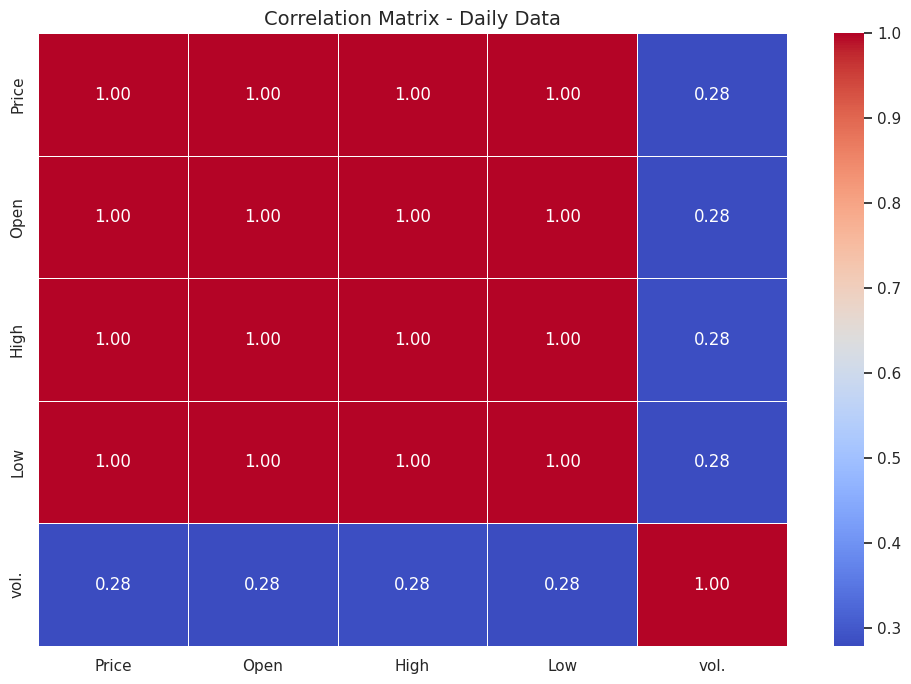


CORRELATION MATRIX - MONTHLY
        Price    Open    High     Low    vol.
Price  1.0000  0.9957  0.9984  0.9977  0.5178
Open   0.9957  1.0000  0.9984  0.9977  0.5197
High   0.9984  0.9984  1.0000  0.9983  0.5219
Low    0.9977  0.9977  0.9983  1.0000  0.5137
vol.   0.5178  0.5197  0.5219  0.5137  1.0000


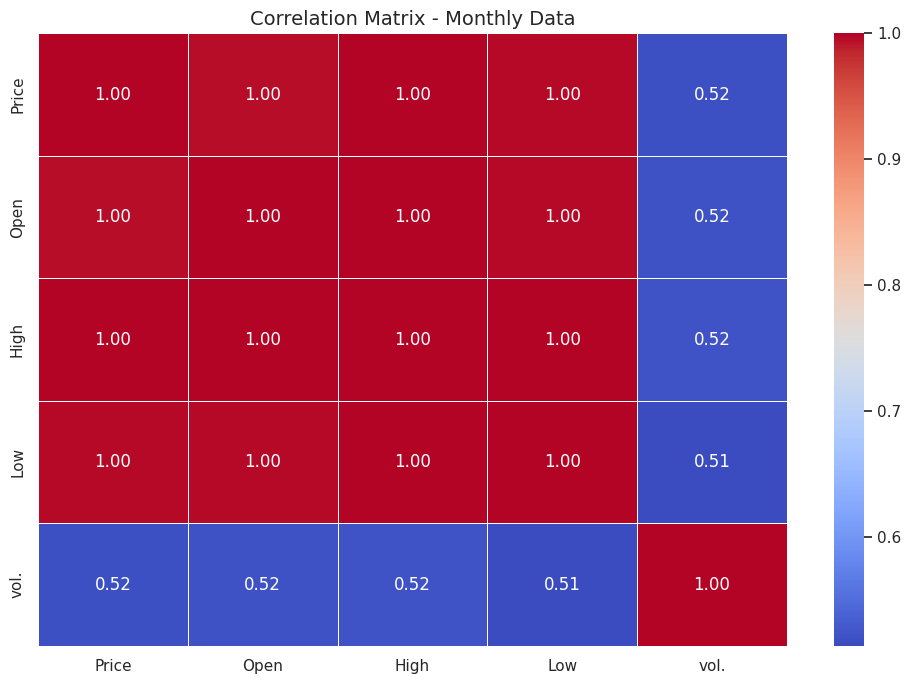


CORRELATION MATRIX - YEARLY
        Price    Open    High     Low    vol.
Price  1.0000  0.9999  0.9998  0.9999  0.4398
Open   0.9999  1.0000  0.9998  0.9996  0.4384
High   0.9998  0.9998  1.0000  0.9996  0.4430
Low    0.9999  0.9996  0.9996  1.0000  0.4411
vol.   0.4398  0.4384  0.4430  0.4411  1.0000


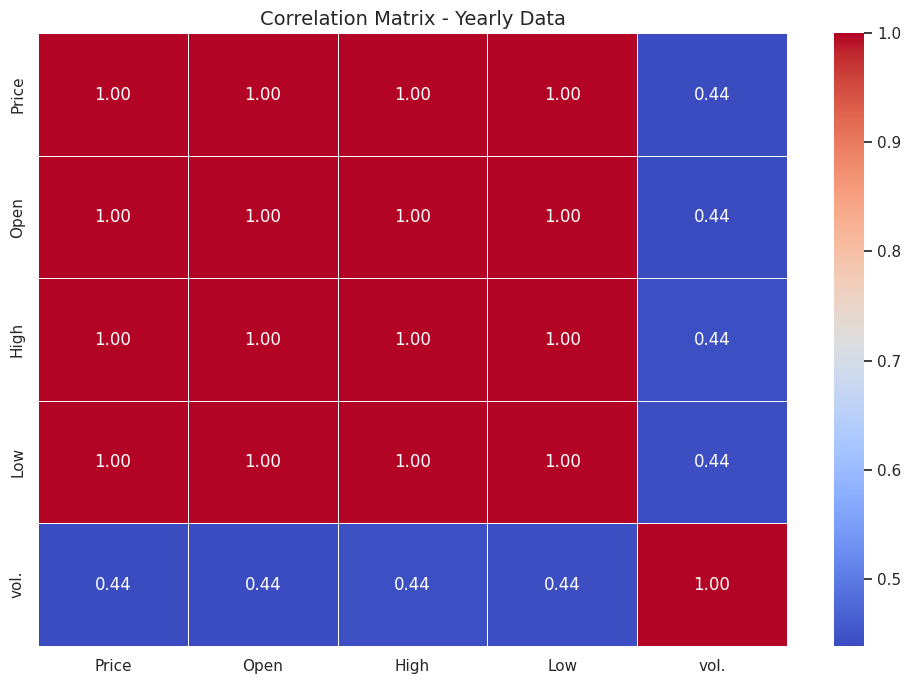

In [36]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_results = {}

for name, df in clean_datasets.items():

    numeric_df = df.select_dtypes(
        include=np.number
    )

    corr = numeric_df.corr()

    correlation_results[name] = corr

    print("\n" + "=" * 80)
    print(f"CORRELATION MATRIX - {name.upper()}")
    print("=" * 80)

    print(corr.round(4))

    plt.figure(figsize=(10, 7))

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5
    )

    plt.title(
        f"Correlation Matrix - {name} Data"
    )

    plt.tight_layout()
    plt.show()

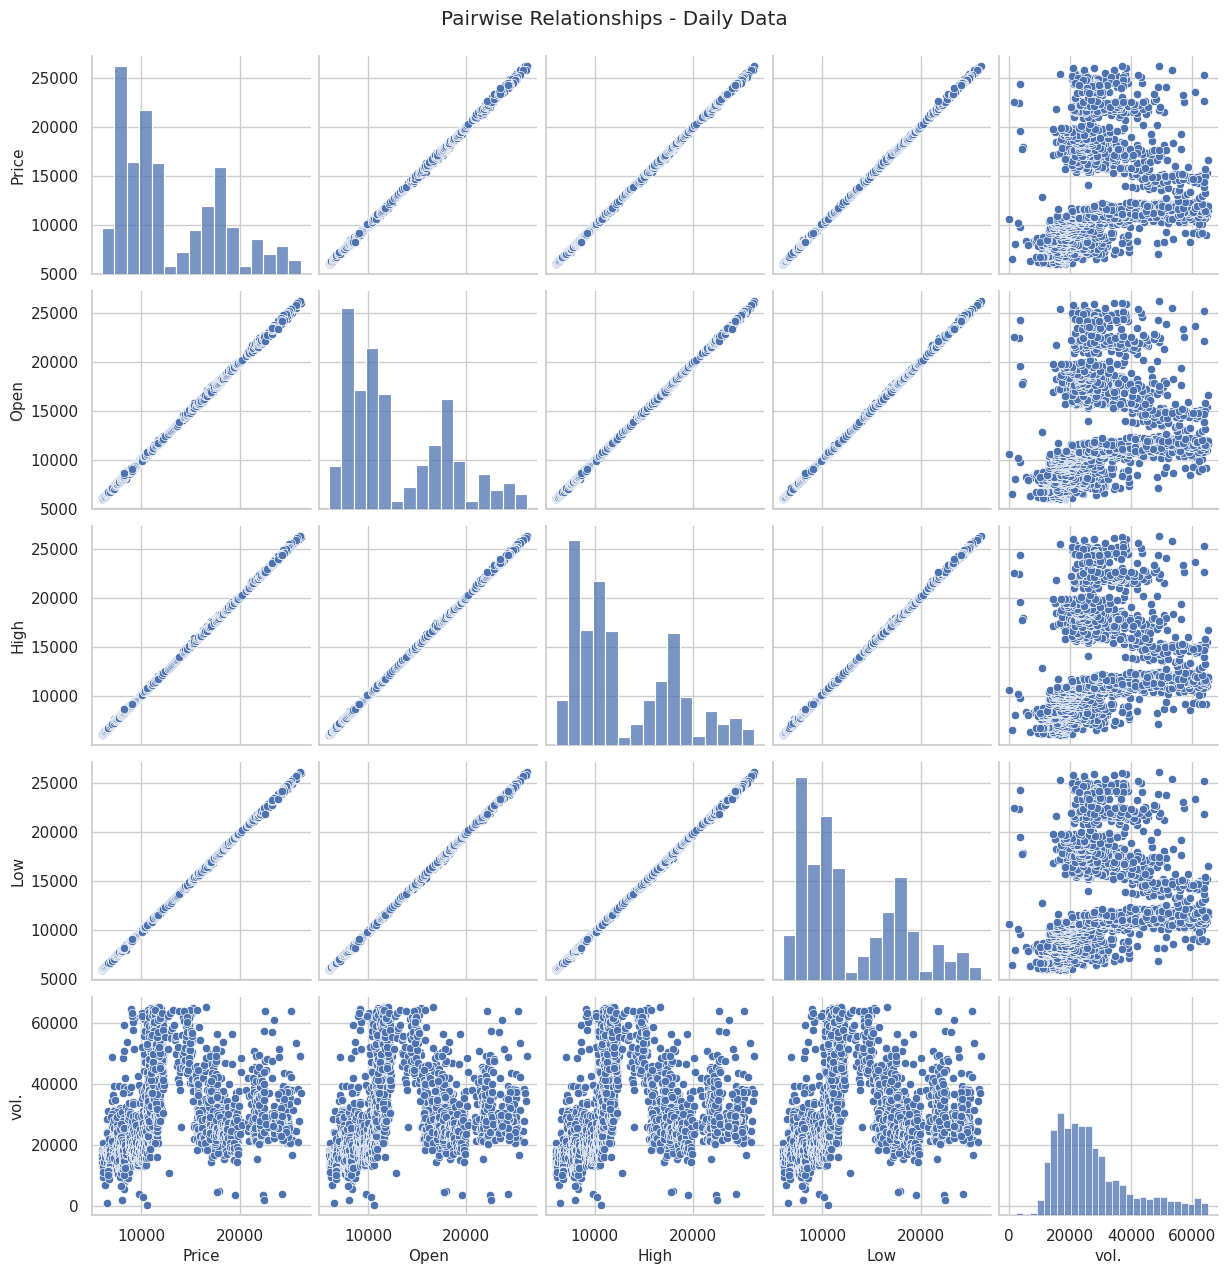

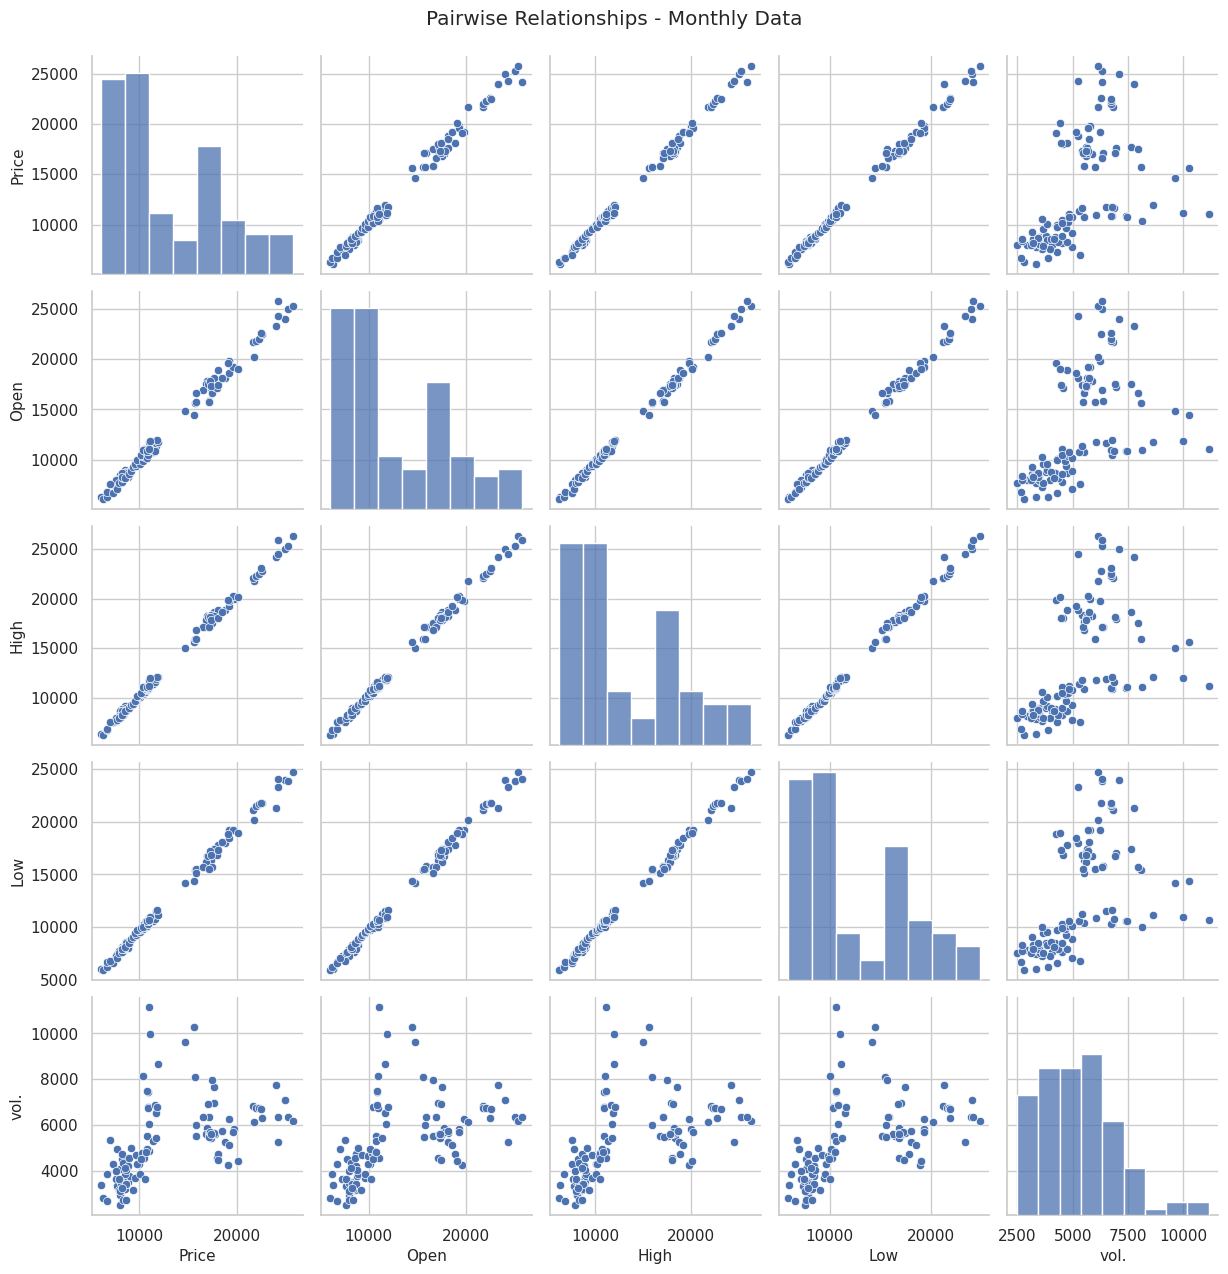

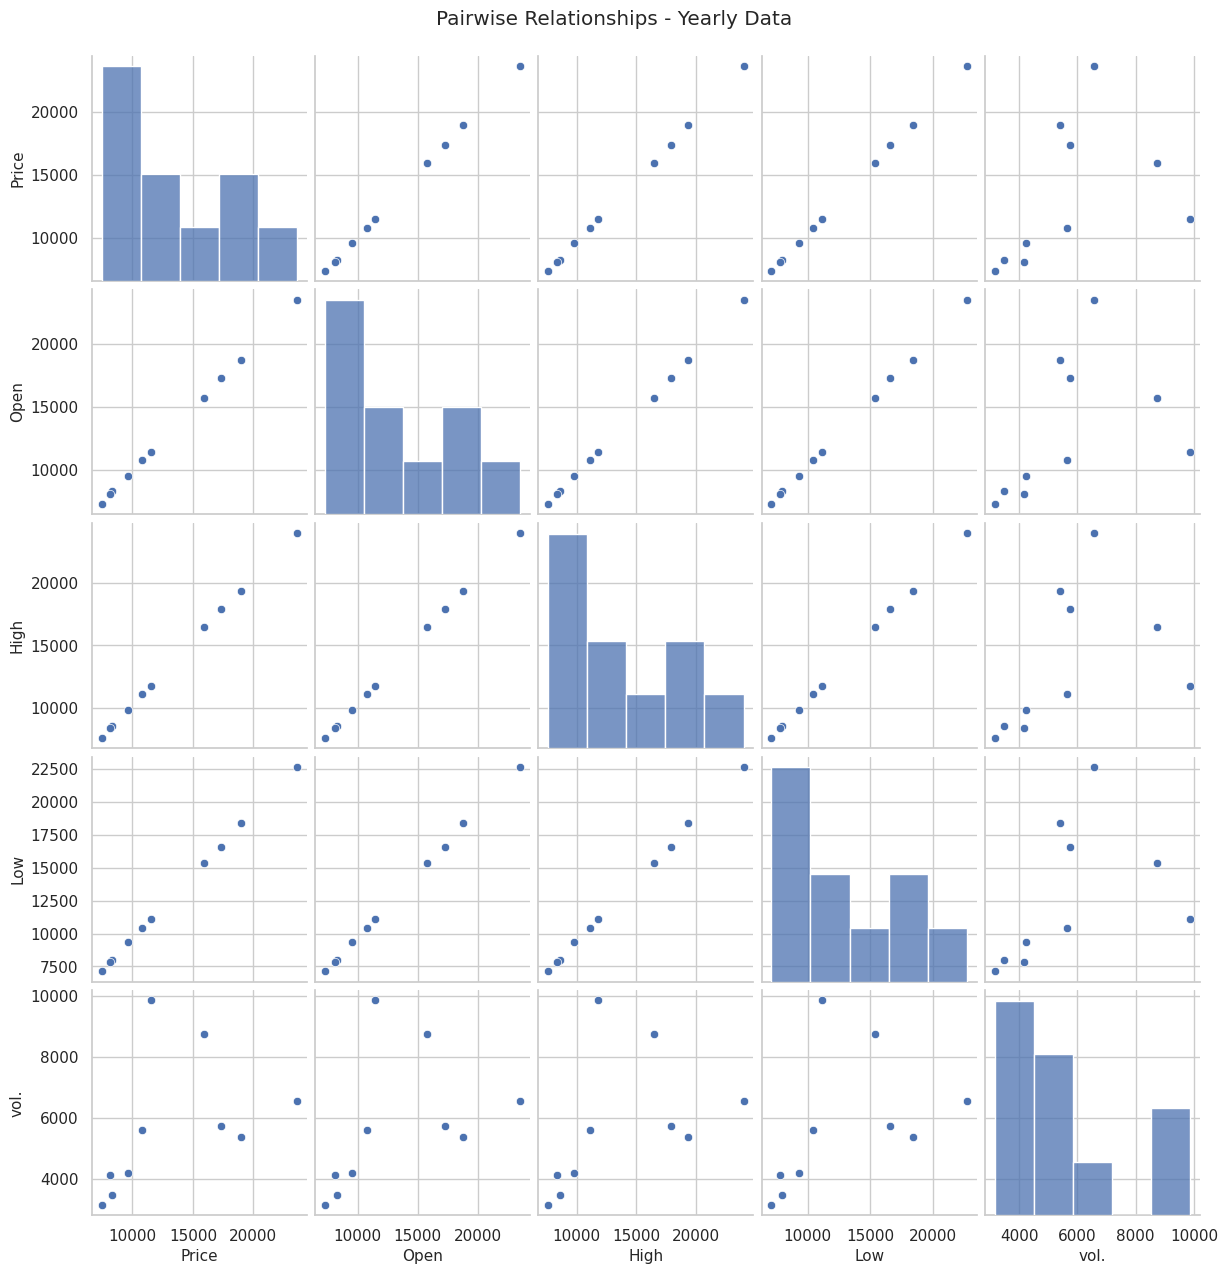

In [37]:
# ============================================================
# PAIRWISE RELATIONSHIPS
# ============================================================

for name, df in clean_datasets.items():

    numeric_df = df.select_dtypes(
        include=np.number
    )

    # Pairplot can become very large, therefore use
    # maximum six variables if necessary.

    selected_columns = numeric_df.columns[:6]

    sns.pairplot(
        numeric_df[selected_columns],
        diag_kind="hist"
    )

    plt.suptitle(
        f"Pairwise Relationships - {name} Data",
        y=1.02
    )

    plt.show()

In [38]:
# ============================================================
# COMPARATIVE ANALYSIS
# ============================================================

comparison_rows = []


for name, df in clean_datasets.items():

    numeric_df = df.select_dtypes(
        include=np.number
    )

    for col in numeric_df.columns:

        mean_value = numeric_df[col].mean()
        std_value = numeric_df[col].std()

        if mean_value != 0:

            cv = (
                std_value /
                abs(mean_value)
            ) * 100

        else:

            cv = np.nan


        comparison_rows.append({

            "Dataset": name,

            "Variable": col,

            "Mean": mean_value,

            "Median": numeric_df[col].median(),

            "Standard Deviation": std_value,

            "Variance": numeric_df[col].var(),

            "Minimum": numeric_df[col].min(),

            "Maximum": numeric_df[col].max(),

            "Range": (
                numeric_df[col].max()
                -
                numeric_df[col].min()
            ),

            "Skewness": numeric_df[col].skew(),

            "Kurtosis": numeric_df[col].kurtosis(),

            "Coefficient of Variation (%)": cv
        })


comparison_table = pd.DataFrame(
    comparison_rows
)


print("\n" + "=" * 80)
print("DAILY VS MONTHLY VS YEARLY COMPARATIVE ANALYSIS")
print("=" * 80)

print(comparison_table.round(4))


DAILY VS MONTHLY VS YEARLY COMPARATIVE ANALYSIS
    Dataset Variable        Mean     Median  Standard Deviation      Variance  \
0     Daily    Price  12947.8935  11000.200           5095.2147  2.596121e+07   
1     Daily     Open  12955.9396  10996.725           5095.7926  2.596710e+07   
2     Daily     High  13012.1083  11050.850           5116.5840  2.617943e+07   
3     Daily      Low  12880.1750  10923.650           5070.7815  2.571282e+07   
4     Daily     vol.  27735.1668  24492.000          12982.5357  1.685462e+08   
5   Monthly    Price  13099.7121  10846.750           5372.4573  2.886330e+07   
6   Monthly     Open  12999.5942  10847.000           5324.4256  2.834951e+07   
7   Monthly     High  13394.0018  11076.500           5473.3771  2.995786e+07   
8   Monthly      Low  12606.7397  10484.350           5168.9559  2.671811e+07   
9   Monthly     vol.   5220.7143   4970.000           1735.2948  3.011248e+06   
10   Yearly    Price  13176.7032  11180.925           5475.1

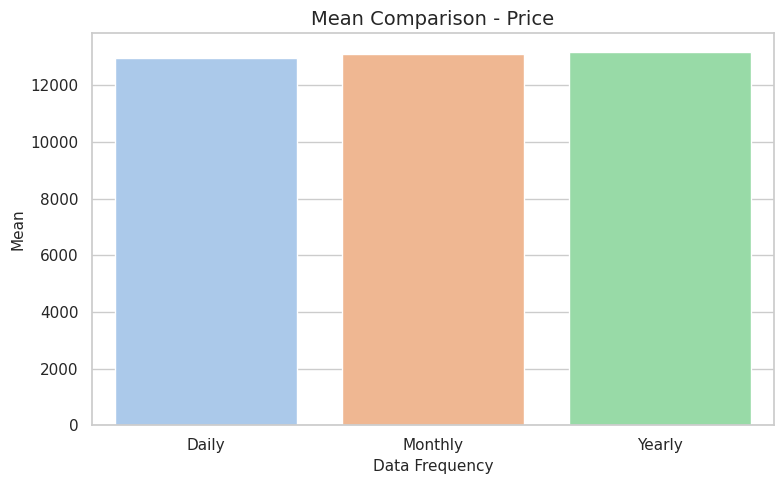

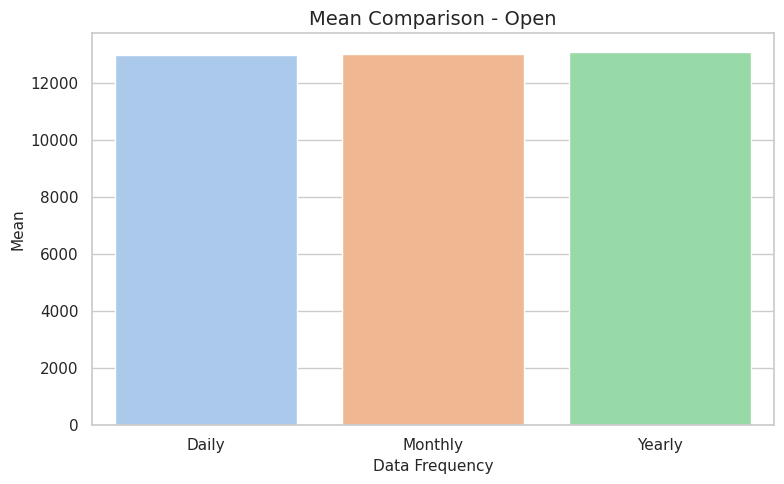

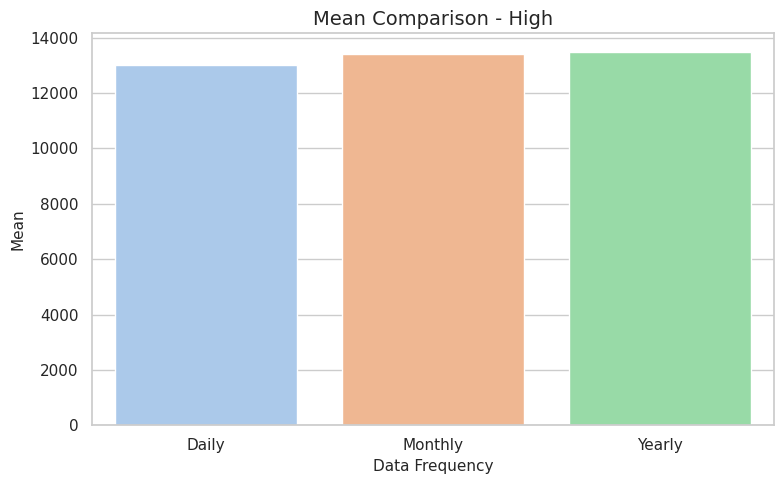

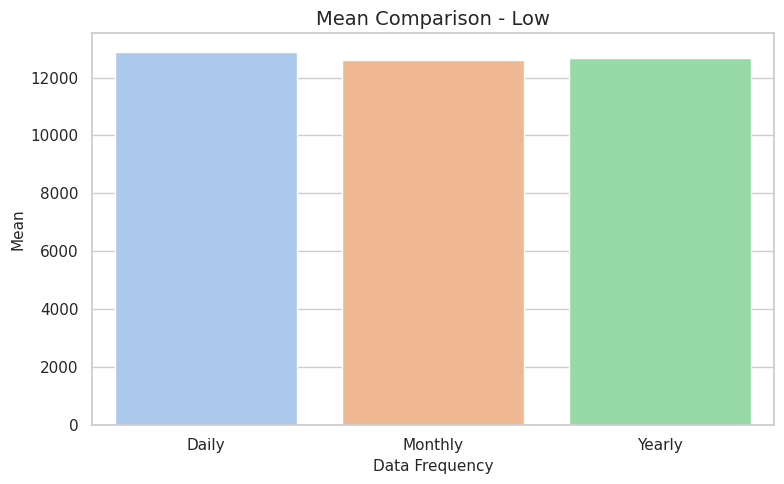

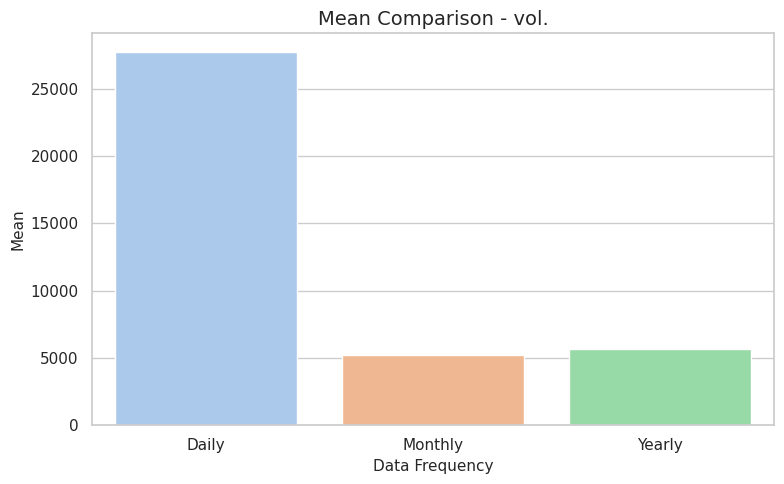

In [39]:
# ============================================================
# COMPARATIVE MEAN PLOTS
# ============================================================

for variable in comparison_table["Variable"].unique():

    temp = comparison_table[
        comparison_table["Variable"] == variable
    ]

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=temp,
        x="Dataset",
        y="Mean",
        palette="pastel"
    )

    plt.title(
        f"Mean Comparison - {variable}"
    )

    plt.xlabel("Data Frequency")
    plt.ylabel("Mean")

    plt.tight_layout()
    plt.show()

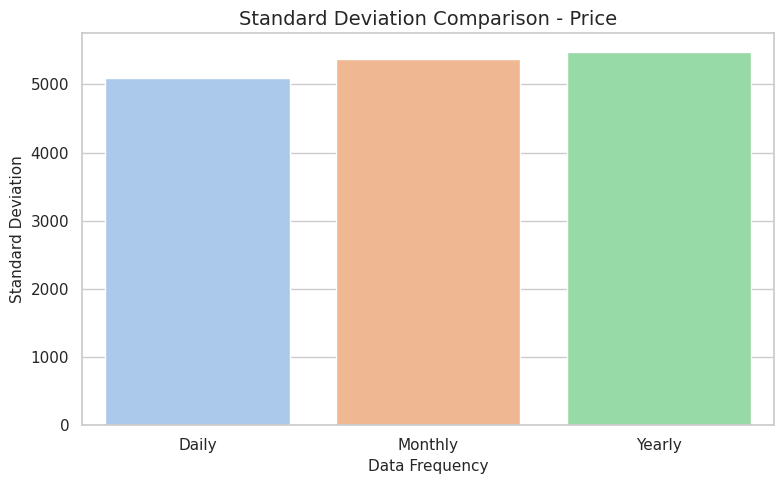

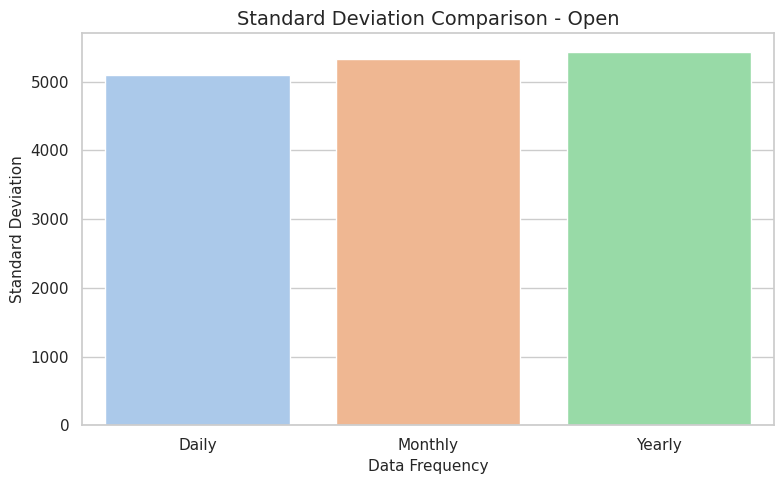

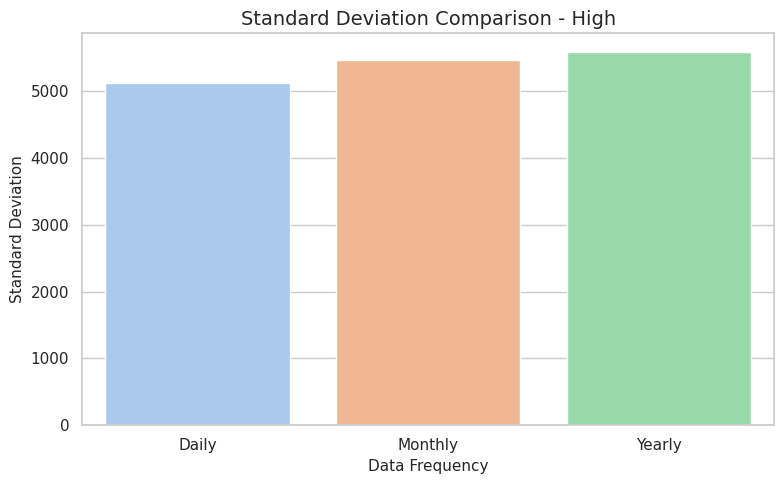

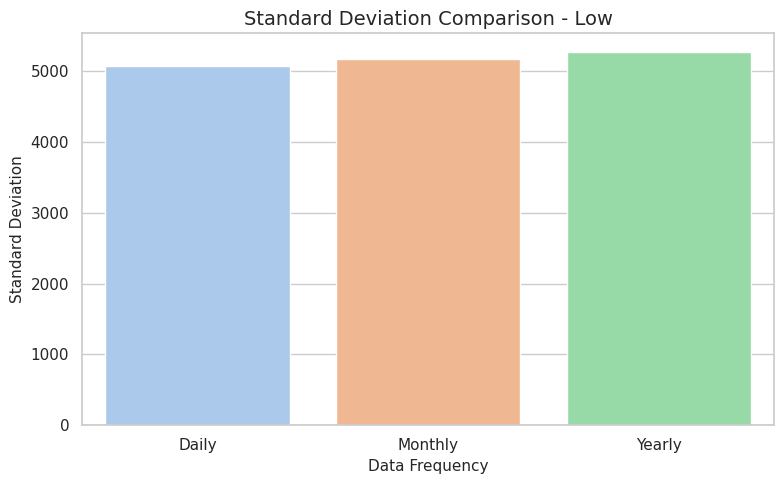

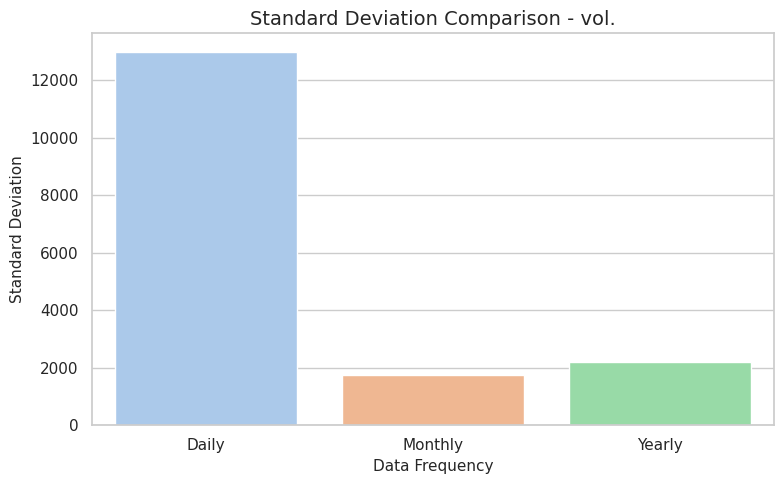

In [40]:
# ============================================================
# COMPARATIVE STANDARD DEVIATION
# ============================================================

for variable in comparison_table["Variable"].unique():

    temp = comparison_table[
        comparison_table["Variable"] == variable
    ]

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=temp,
        x="Dataset",
        y="Standard Deviation",
        palette="pastel"
    )

    plt.title(
        f"Standard Deviation Comparison - {variable}"
    )

    plt.xlabel("Data Frequency")
    plt.ylabel("Standard Deviation")

    plt.tight_layout()
    plt.show()

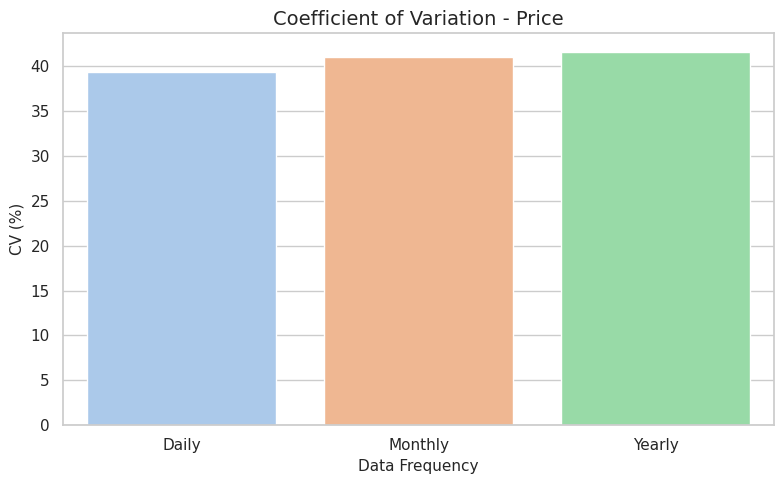

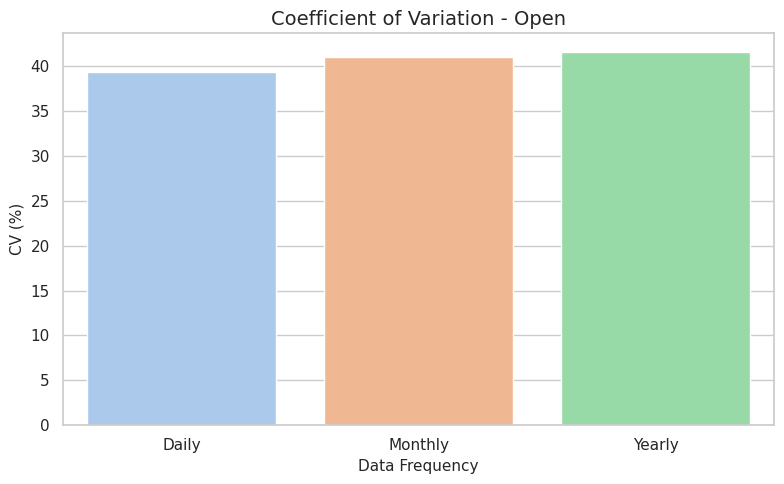

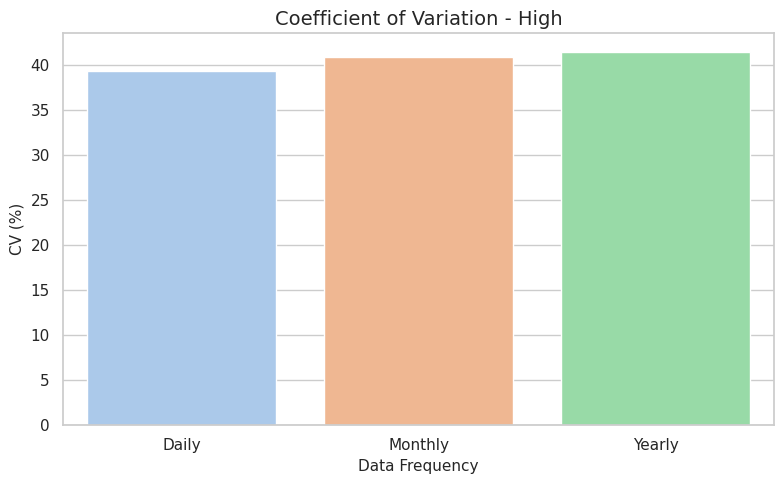

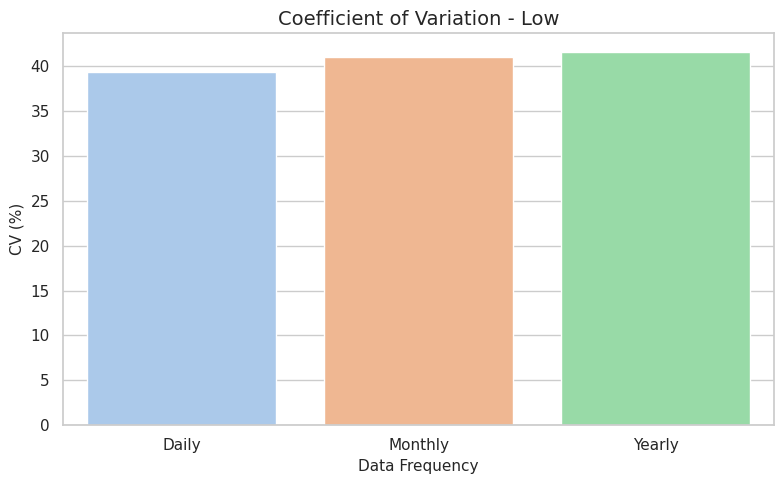

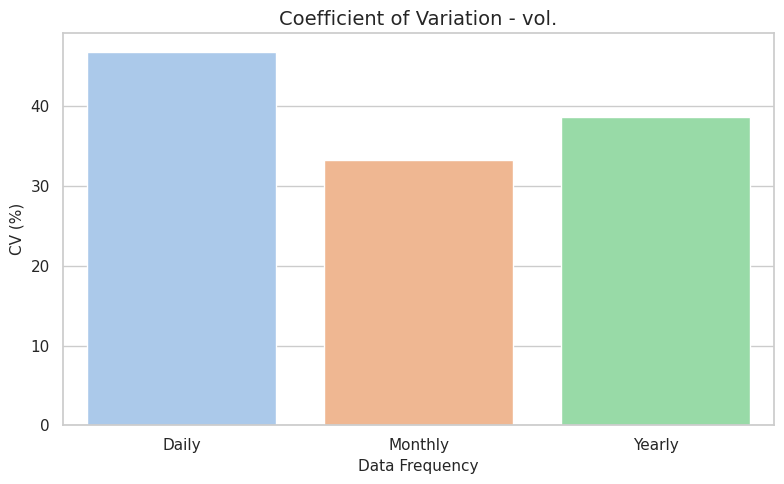

In [41]:
# ============================================================
# COEFFICIENT OF VARIATION
# ============================================================

for variable in comparison_table["Variable"].unique():

    temp = comparison_table[
        comparison_table["Variable"] == variable
    ]

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=temp,
        x="Dataset",
        y="Coefficient of Variation (%)",
        palette="pastel"
    )

    plt.title(
        f"Coefficient of Variation - {variable}"
    )

    plt.xlabel("Data Frequency")
    plt.ylabel("CV (%)")

    plt.tight_layout()
    plt.show()

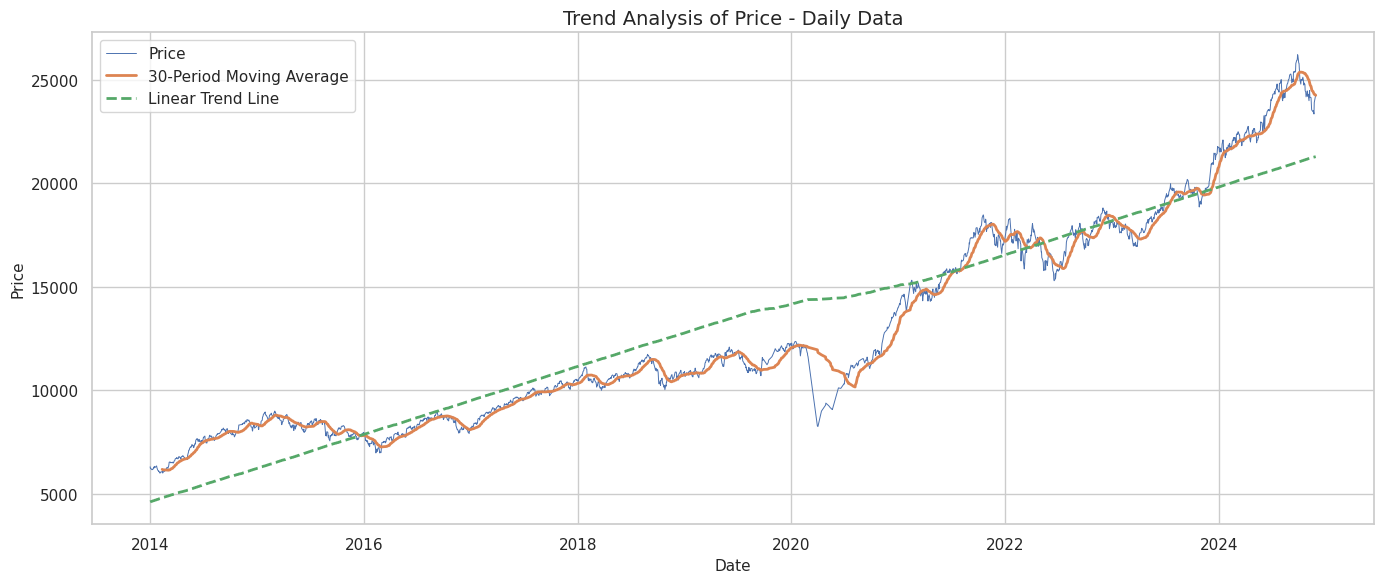

Daily - Price: Slope=6.627181, R²=0.8942, p-value=0.000000


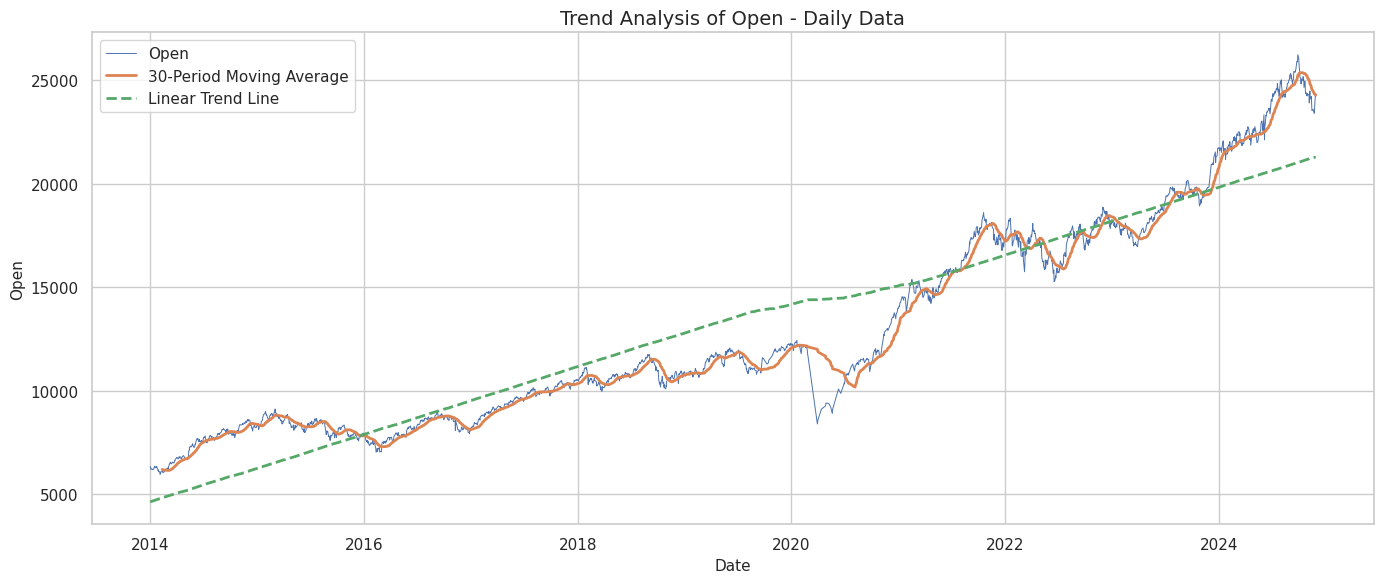

Daily - Open: Slope=6.628487, R²=0.8944, p-value=0.000000


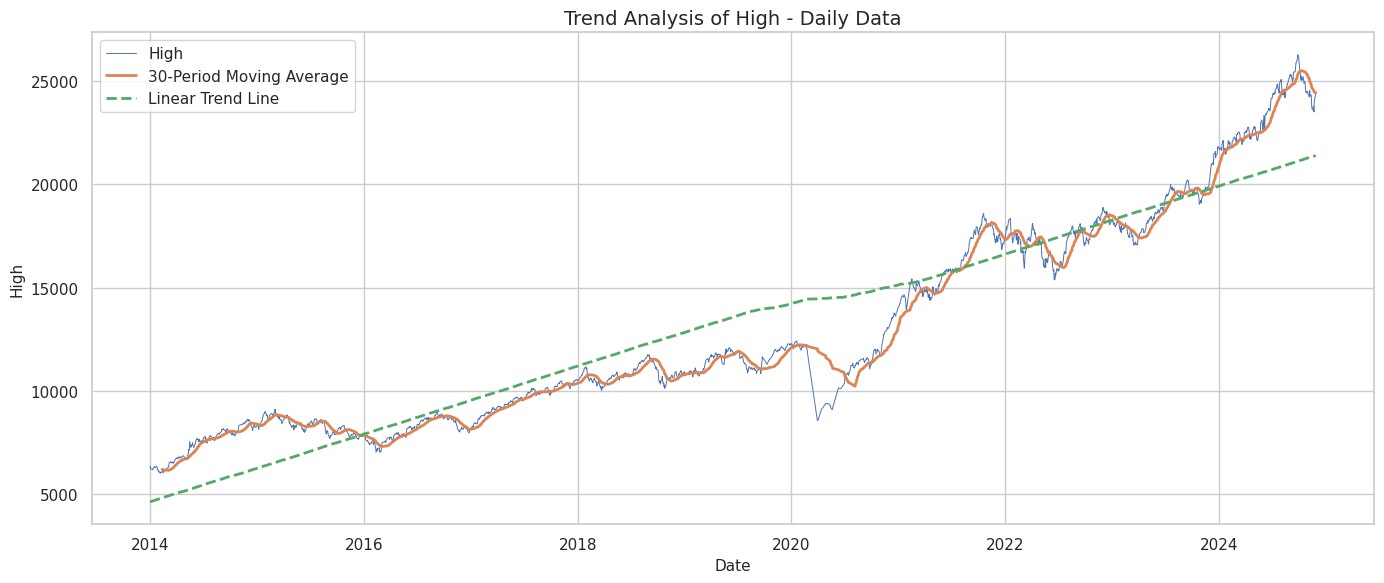

Daily - High: Slope=6.655775, R²=0.8944, p-value=0.000000


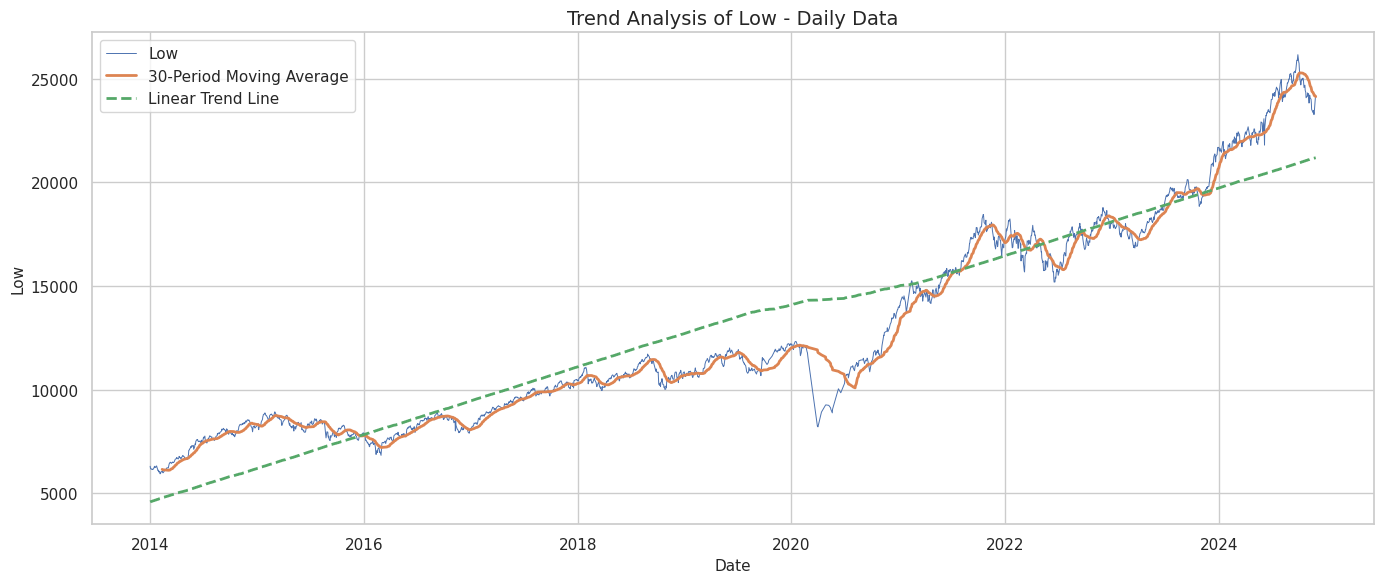

Daily - Low: Slope=6.594564, R²=0.8940, p-value=0.000000


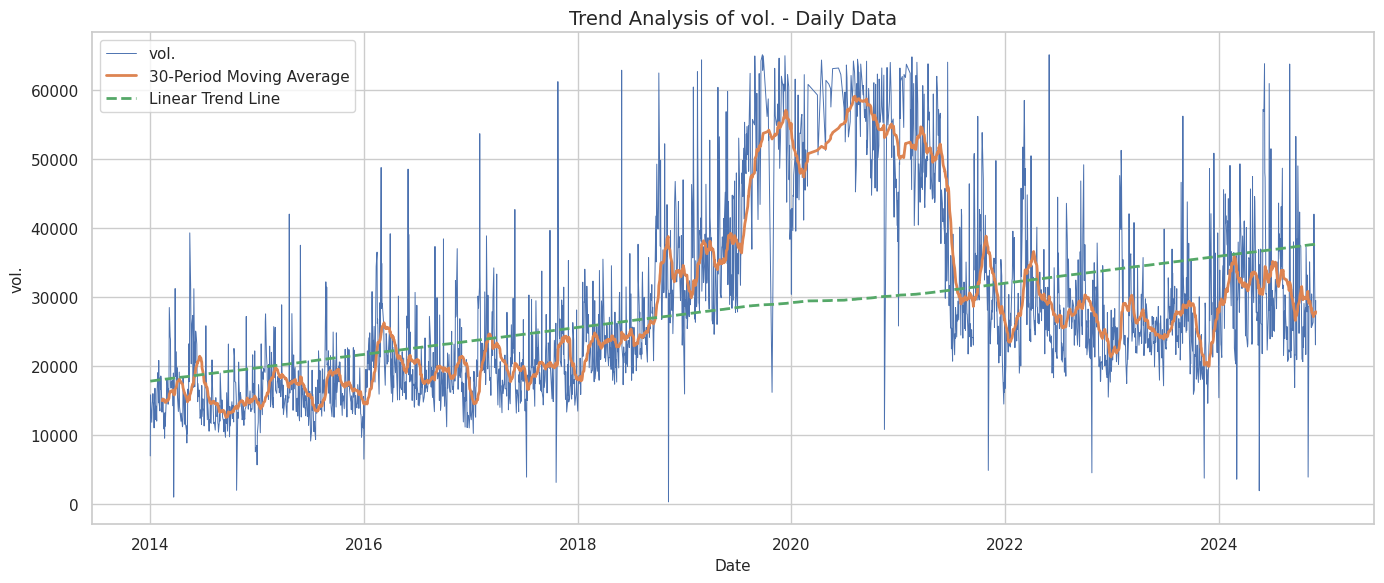

Daily - vol.: Slope=7.893106, R²=0.1954, p-value=0.000000


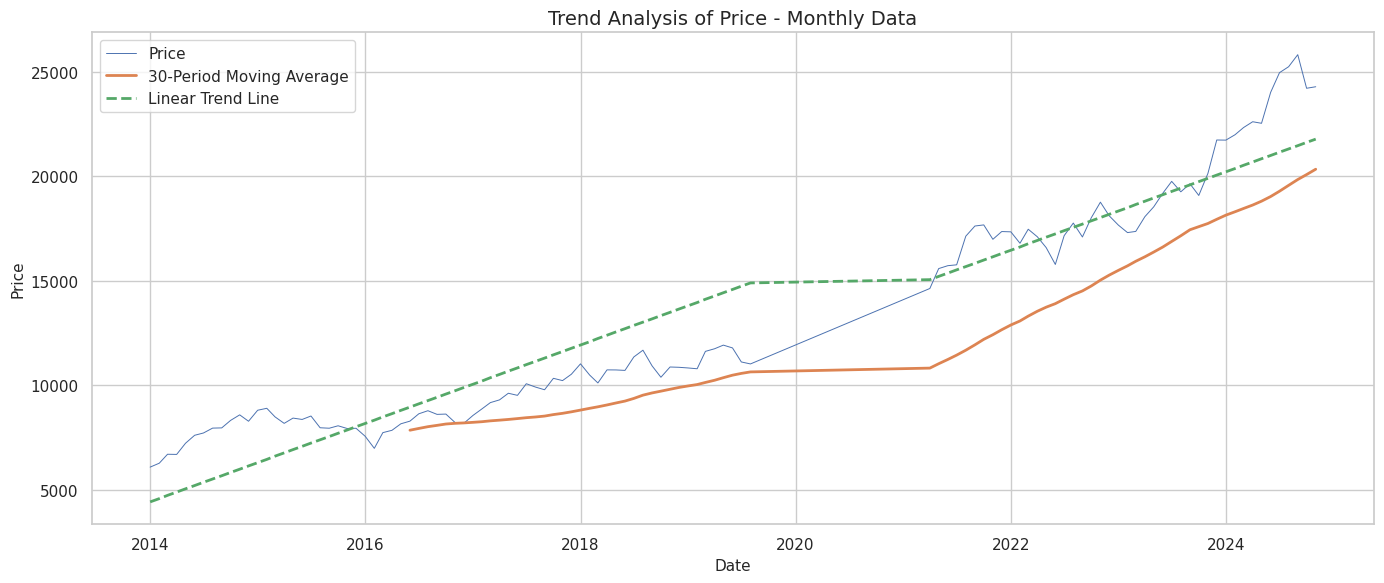

Monthly - Price: Slope=156.277082, R²=0.8924, p-value=0.000000


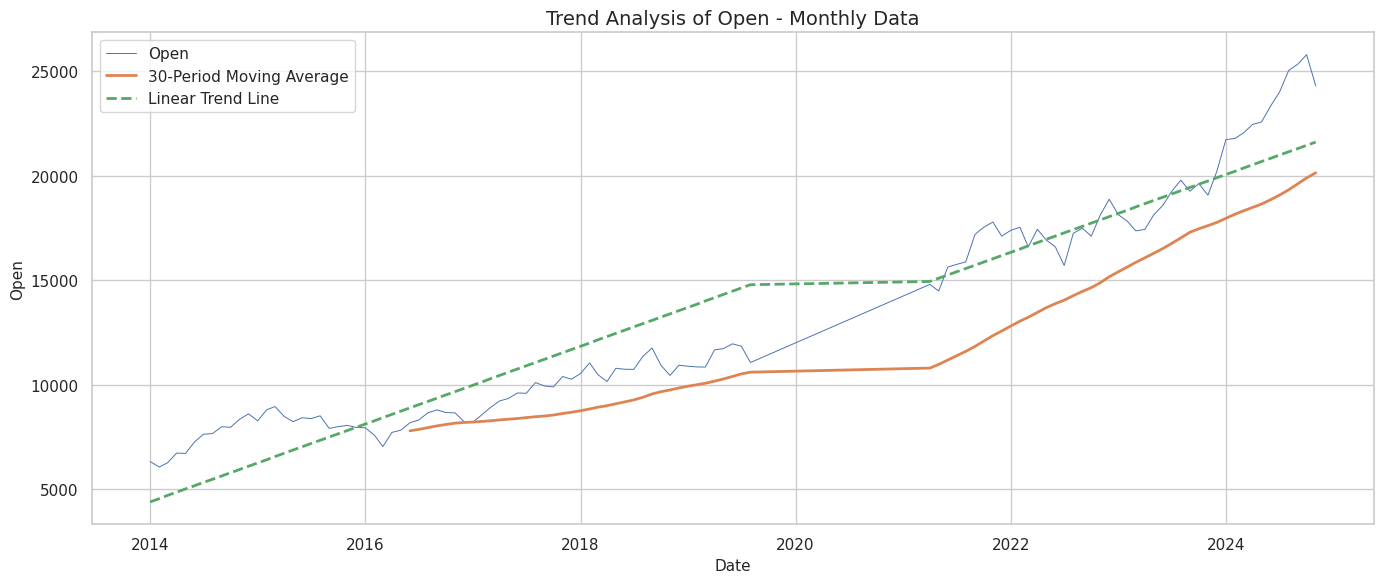

Monthly - Open: Slope=155.089208, R²=0.8948, p-value=0.000000


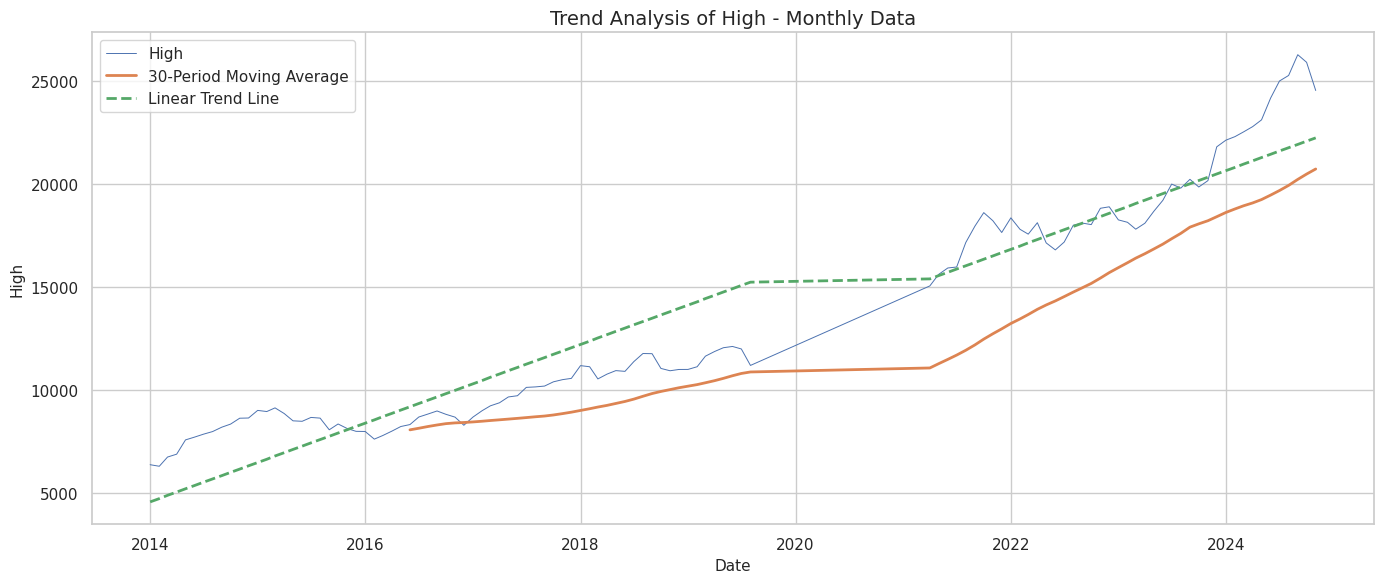

Monthly - High: Slope=159.320610, R²=0.8936, p-value=0.000000


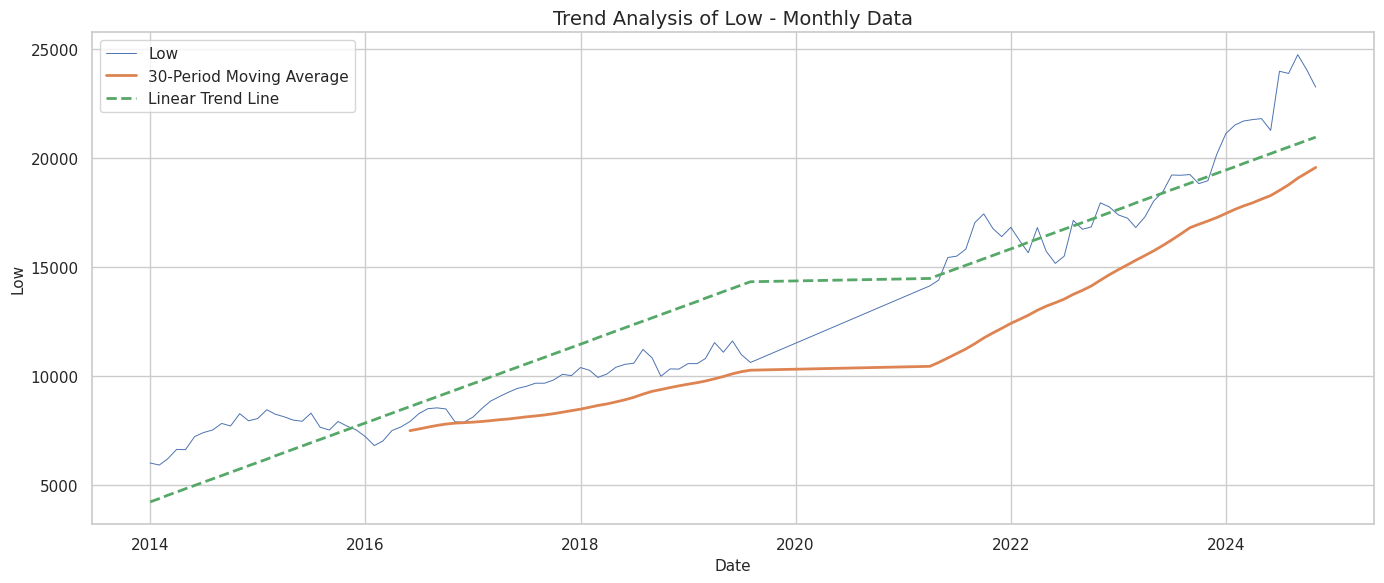

Monthly - Low: Slope=150.690832, R²=0.8964, p-value=0.000000


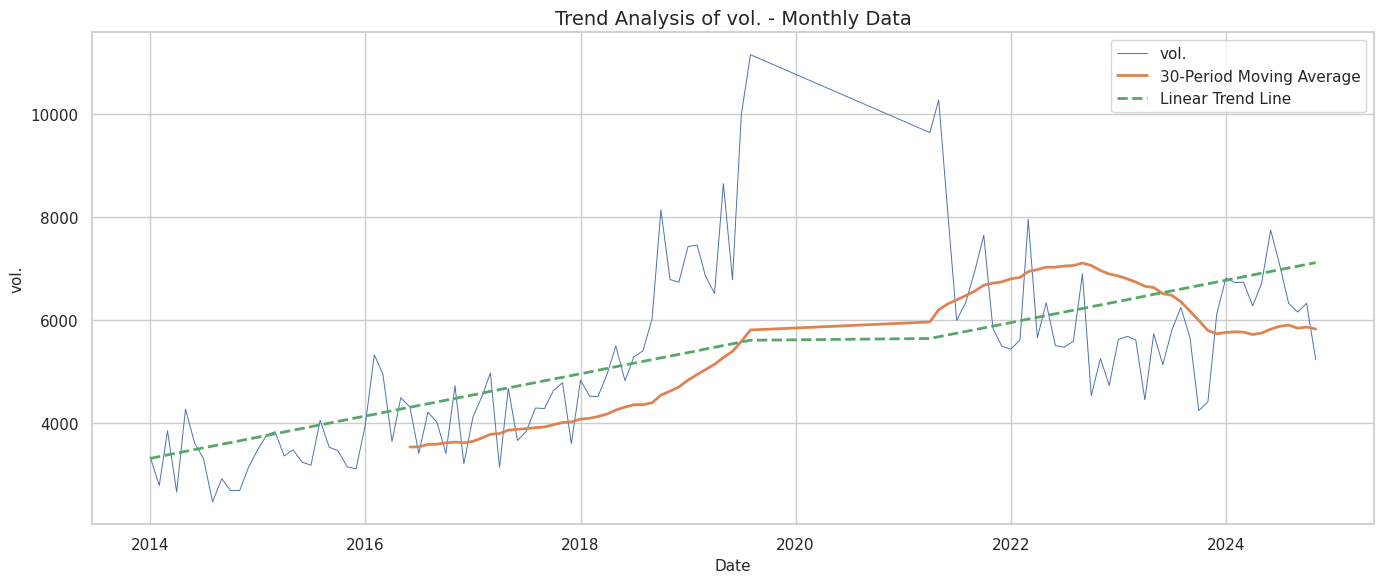

Monthly - vol.: Slope=34.193546, R²=0.4095, p-value=0.000000


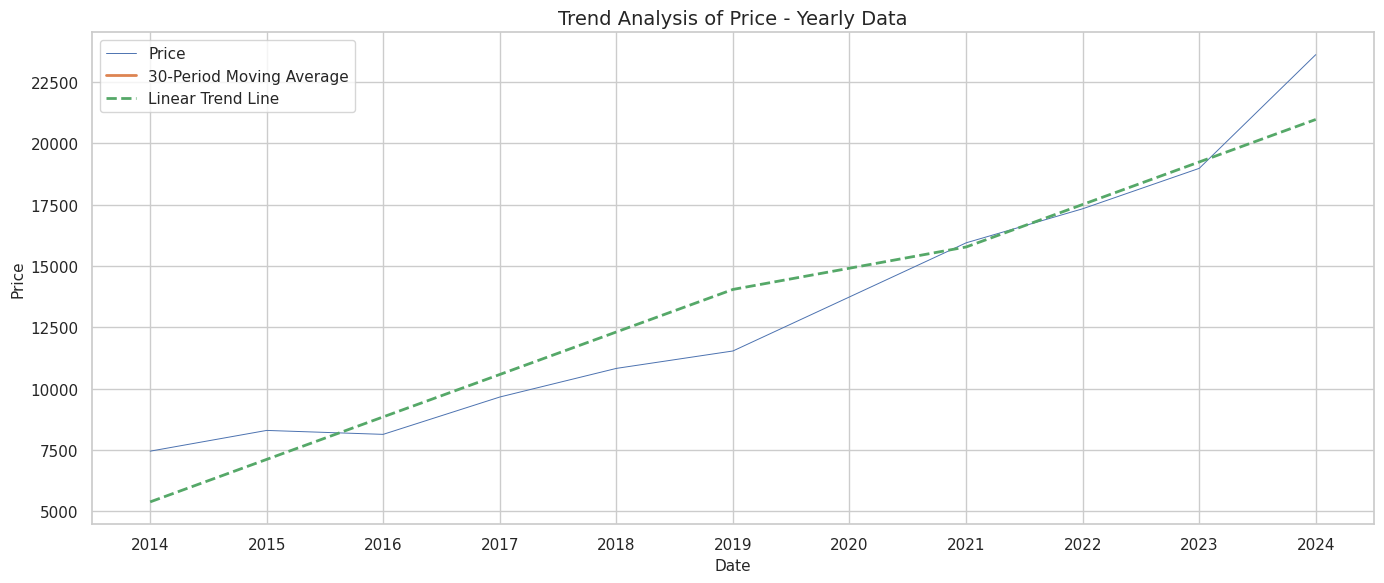

Yearly - Price: Slope=1730.999564, R²=0.9162, p-value=0.000014


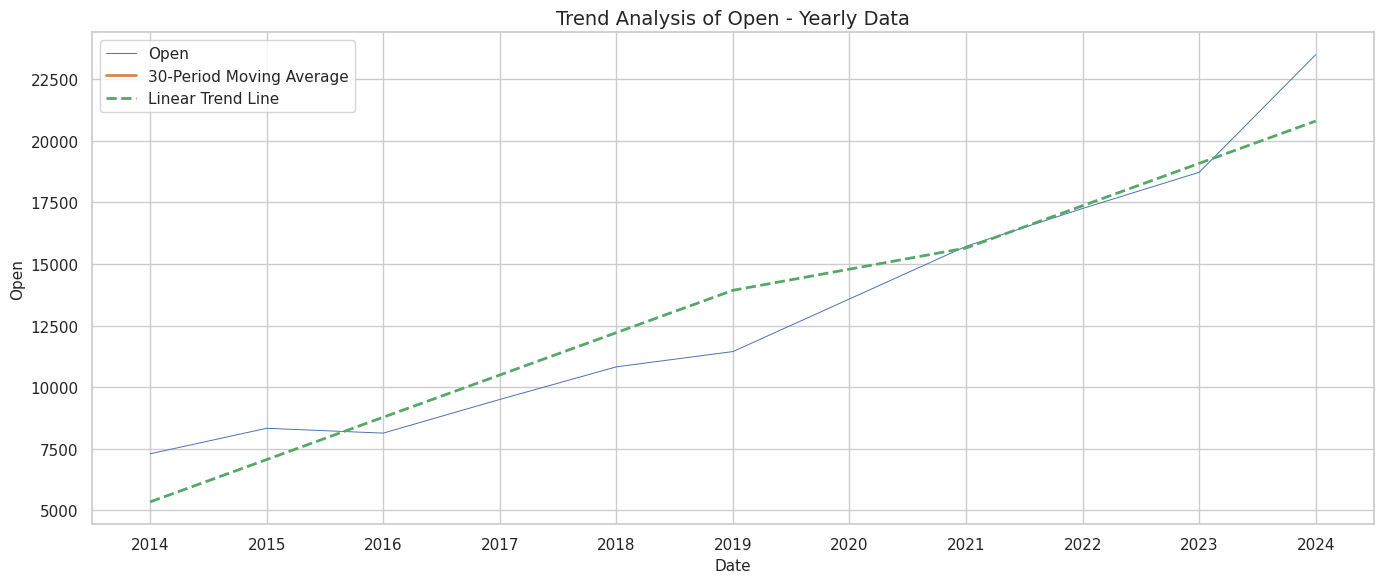

Yearly - Open: Slope=1716.881132, R²=0.9159, p-value=0.000014


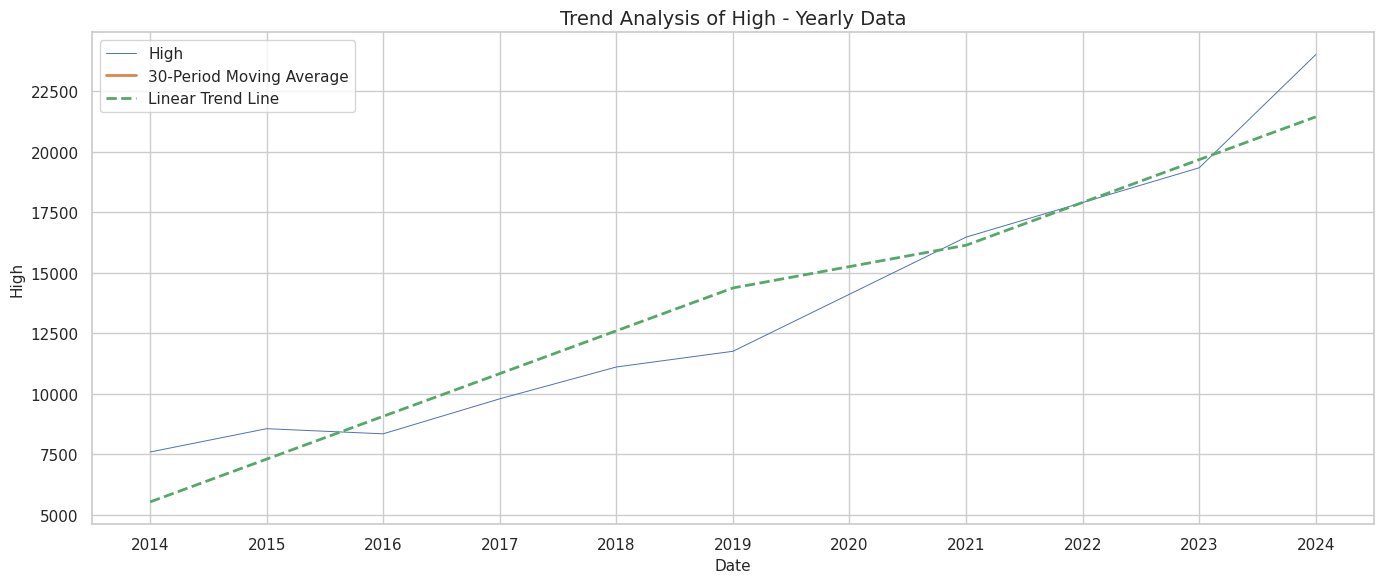

Yearly - High: Slope=1767.331539, R²=0.9170, p-value=0.000013


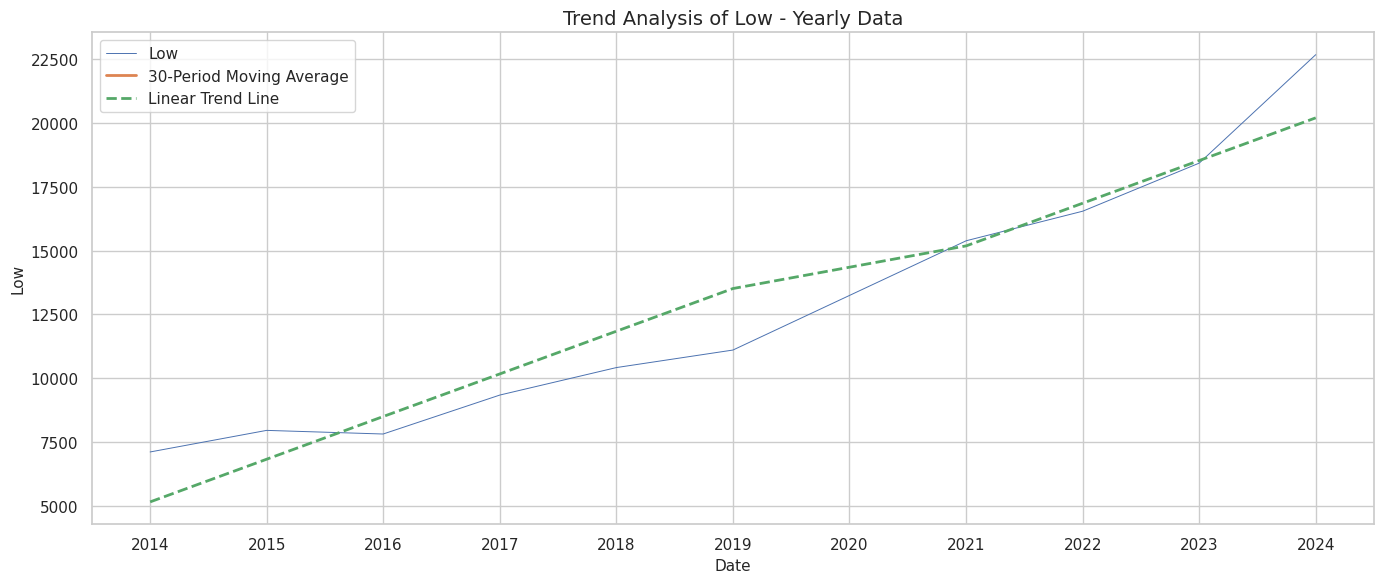

Yearly - Low: Slope=1668.568770, R²=0.9188, p-value=0.000012


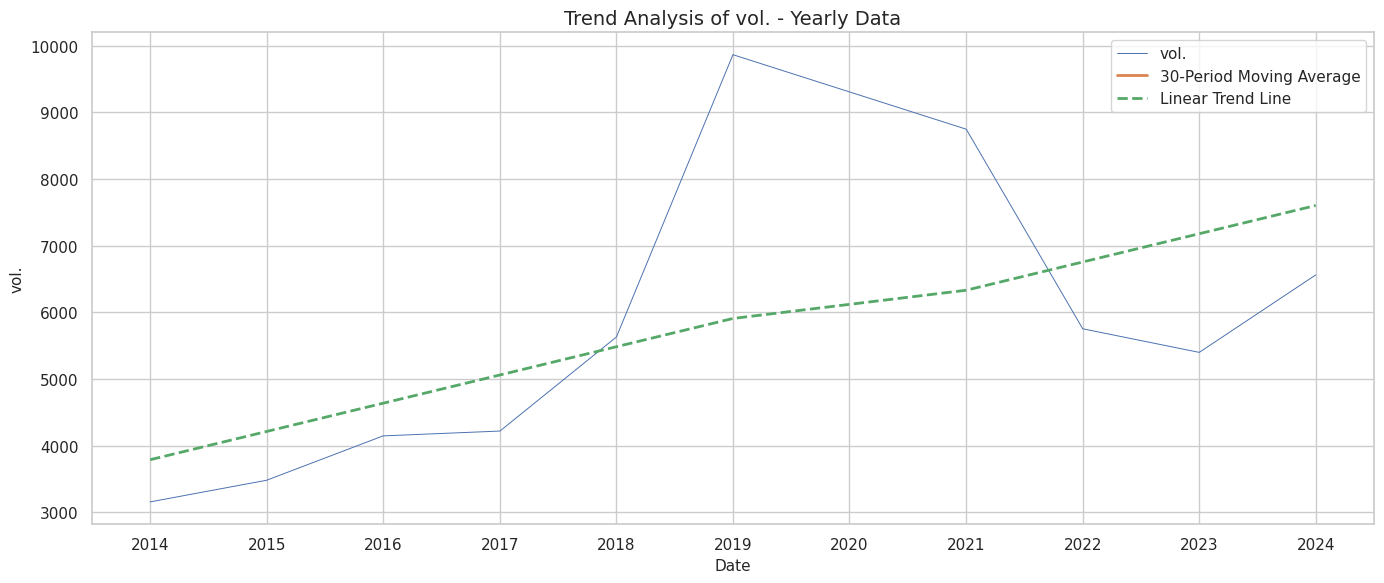

Yearly - vol.: Slope=424.013315, R²=0.3408, p-value=0.076417


In [42]:
# ============================================================
# TREND ANALYSIS
# ============================================================

def trend_analysis(df, dataset_name):

    if "Date" not in df.columns:
        print(
            f"Date column unavailable for {dataset_name}"
        )
        return

    df = df.sort_values("Date").copy()

    numeric_columns = [
        col for col in [
            "Price",
            "Open",
            "High",
            "Low",
            "vol."
        ]
        if col in df.columns
    ]

    for col in numeric_columns:

        # ----------------------------------------------------
        # Moving average
        # ----------------------------------------------------

        window = 30

        moving_average = (
            df[col]
            .rolling(window=window)
            .mean()
        )


        # ----------------------------------------------------
        # Linear regression trend
        # ----------------------------------------------------

        valid = df[
            ["Date", col]
        ].dropna()

        x = np.arange(
            len(valid)
        )

        y = valid[col].values

        slope, intercept, r_value, p_value, std_err = (
            stats.linregress(x, y)
        )

        trend_line = (
            intercept +
            slope * x
        )


        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------

        plt.figure(figsize=(14, 6))

        plt.plot(
            valid["Date"],
            y,
            linewidth=0.7,
            label=f"{col}"
        )

        plt.plot(
            valid["Date"],
            moving_average.loc[
                valid.index
            ],
            linewidth=2,
            label=f"{window}-Period Moving Average"
        )

        plt.plot(
            valid["Date"],
            trend_line,
            linewidth=2,
            linestyle="--",
            label="Linear Trend Line"
        )

        plt.title(
            f"Trend Analysis of {col} - {dataset_name} Data"
        )

        plt.xlabel("Date")
        plt.ylabel(col)

        plt.legend()

        plt.tight_layout()
        plt.show()

        print(
            f"{dataset_name} - {col}: "
            f"Slope={slope:.6f}, "
            f"R²={r_value**2:.4f}, "
            f"p-value={p_value:.6f}"
        )


for name, df in clean_datasets.items():

    trend_analysis(
        df,
        name
    )

In [43]:
# ============================================================
# NORMALITY ANALYSIS
# ============================================================

def normality_tests(df, dataset_name):

    results = []

    numeric_df = df.select_dtypes(
        include=np.number
    )

    for col in numeric_df.columns:

        series = numeric_df[col].dropna()

        # Shapiro-Wilk
        # For very large samples, use a sample to avoid
        # excessive sensitivity.

        if len(series) > 5000:

            shapiro_sample = series.sample(
                5000,
                random_state=42
            )

        else:

            shapiro_sample = series


        shapiro_stat, shapiro_p = shapiro(
            shapiro_sample
        )


        # D'Agostino K²
        if len(series) >= 20:

            normaltest_stat, normaltest_p = normaltest(
                series
            )

        else:

            normaltest_stat = np.nan
            normaltest_p = np.nan


        # Jarque-Bera

        jb_stat, jb_p = jarque_bera(
            series
        )


        results.append({

            "Dataset": dataset_name,

            "Variable": col,

            "Shapiro Statistic": shapiro_stat,

            "Shapiro p-value": shapiro_p,

            "Shapiro Conclusion":
                "Normal"
                if shapiro_p >= 0.05
                else "Non-Normal",

            "Normaltest Statistic": normaltest_stat,

            "Normaltest p-value": normaltest_p,

            "Jarque-Bera Statistic": jb_stat,

            "Jarque-Bera p-value": jb_p,

            "Jarque-Bera Conclusion":
                "Normal"
                if jb_p >= 0.05
                else "Non-Normal"
        })


    return pd.DataFrame(results)


normality_results = []


for name, df in clean_datasets.items():

    result = normality_tests(
        df,
        name
    )

    normality_results.append(result)


normality_table = pd.concat(
    normality_results,
    ignore_index=True
)


print("\n" + "=" * 80)
print("NORMALITY TEST RESULTS")
print("=" * 80)

print(normality_table.round(4))


NORMALITY TEST RESULTS
    Dataset Variable  Shapiro Statistic  Shapiro p-value Shapiro Conclusion  \
0     Daily    Price             0.8986           0.0000         Non-Normal   
1     Daily     Open             0.8988           0.0000         Non-Normal   
2     Daily     High             0.8983           0.0000         Non-Normal   
3     Daily      Low             0.8991           0.0000         Non-Normal   
4     Daily     vol.             0.9061           0.0000         Non-Normal   
5   Monthly    Price             0.8842           0.0000         Non-Normal   
6   Monthly     Open             0.8888           0.0000         Non-Normal   
7   Monthly     High             0.8828           0.0000         Non-Normal   
8   Monthly      Low             0.8880           0.0000         Non-Normal   
9   Monthly     vol.             0.9467           0.0002         Non-Normal   
10   Yearly    Price             0.8982           0.2095             Normal   
11   Yearly     Open        

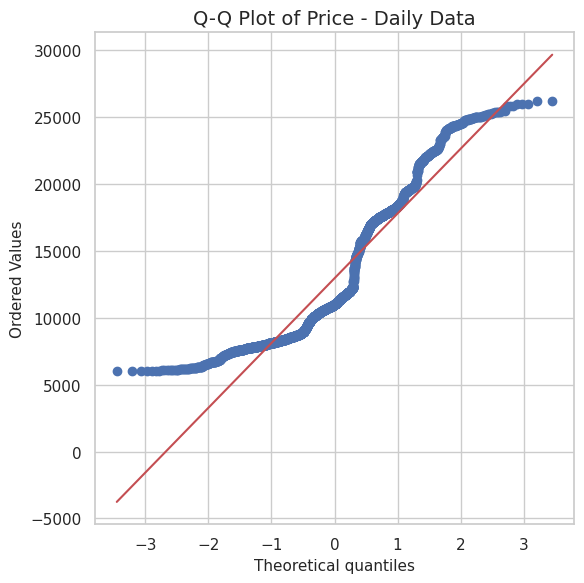

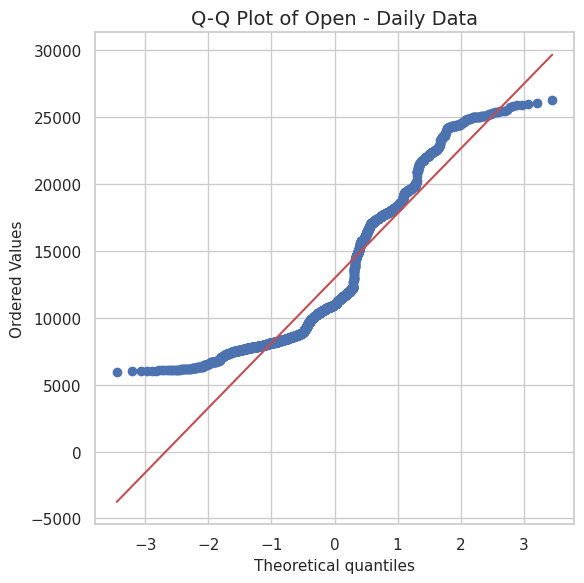

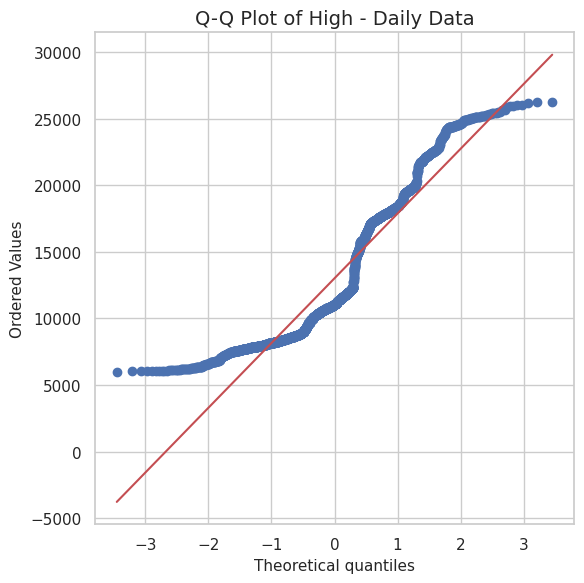

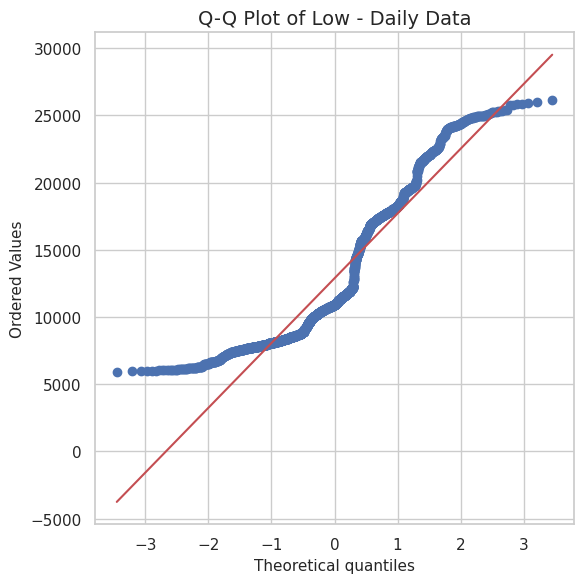

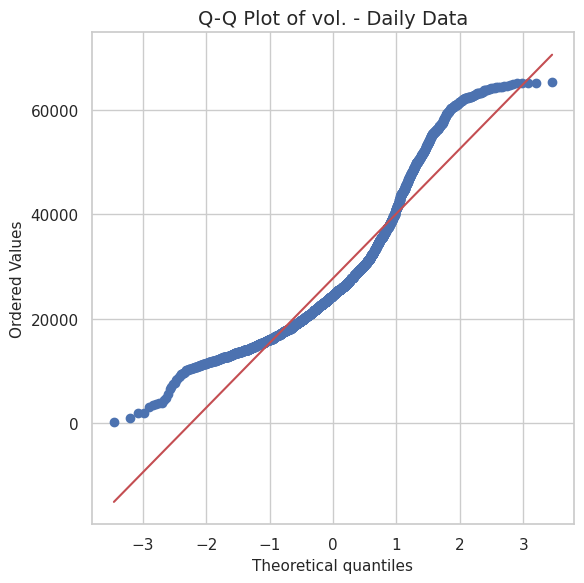

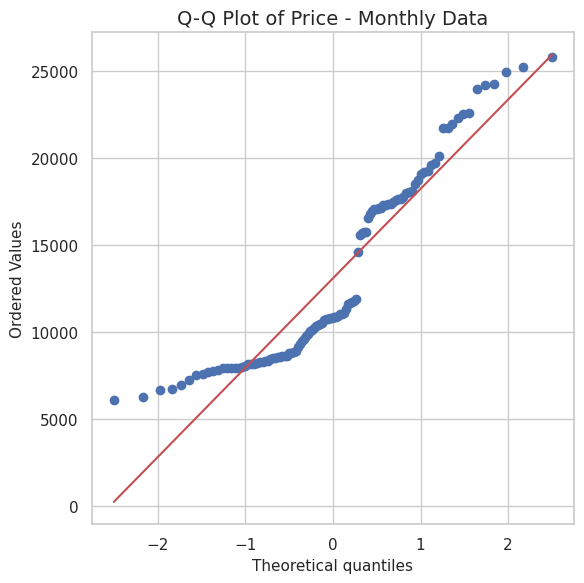

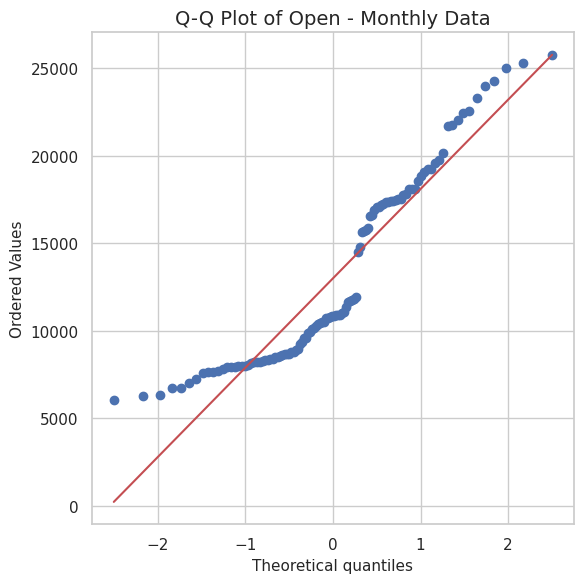

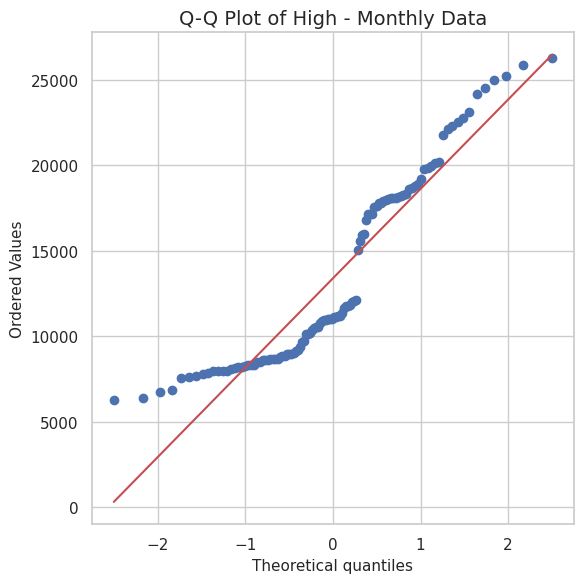

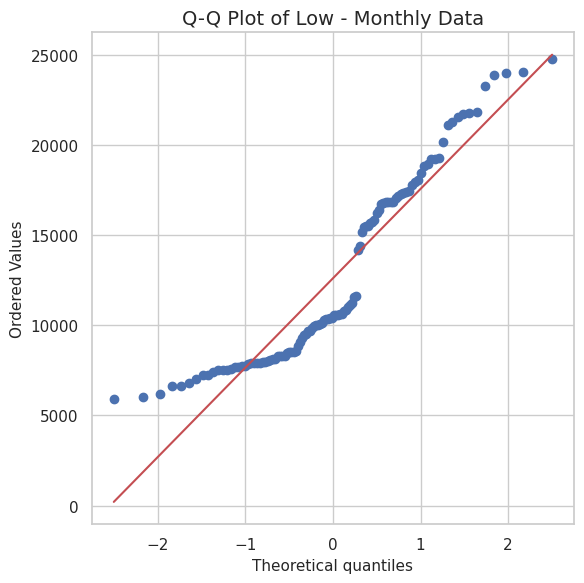

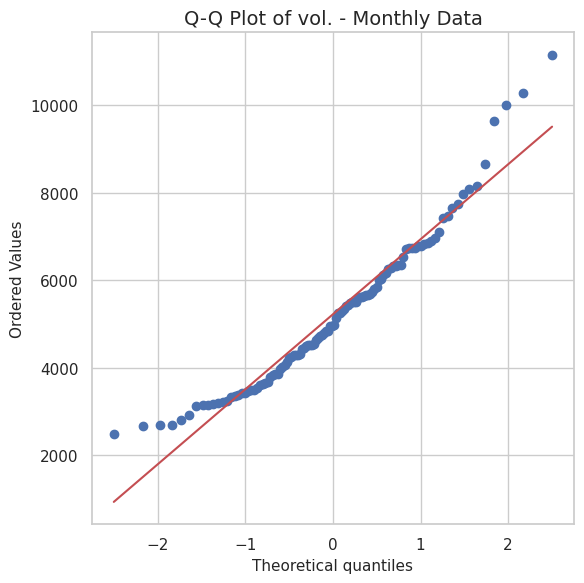

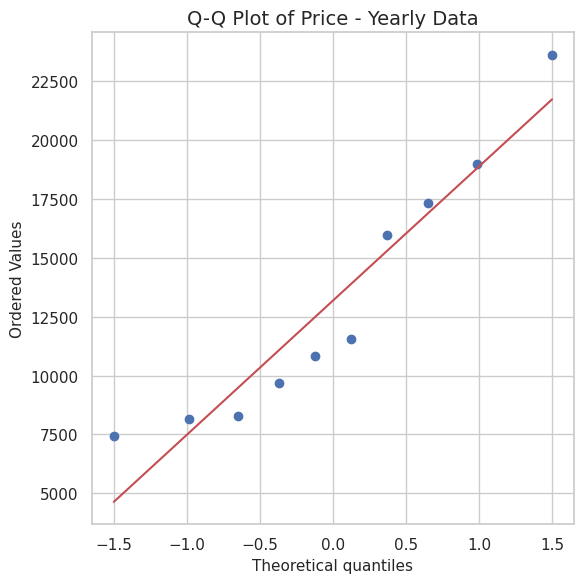

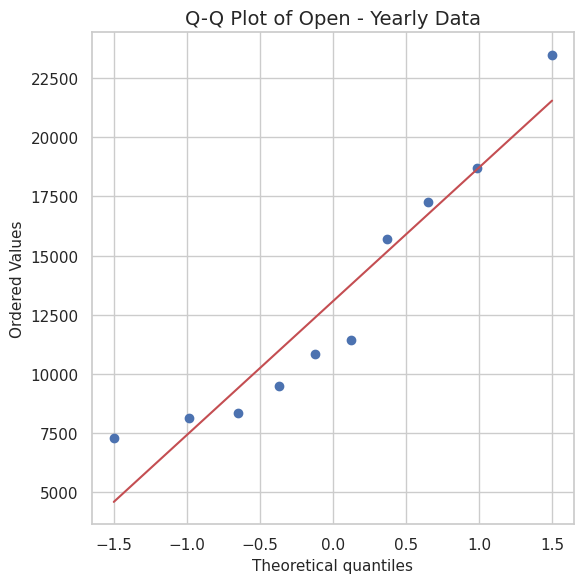

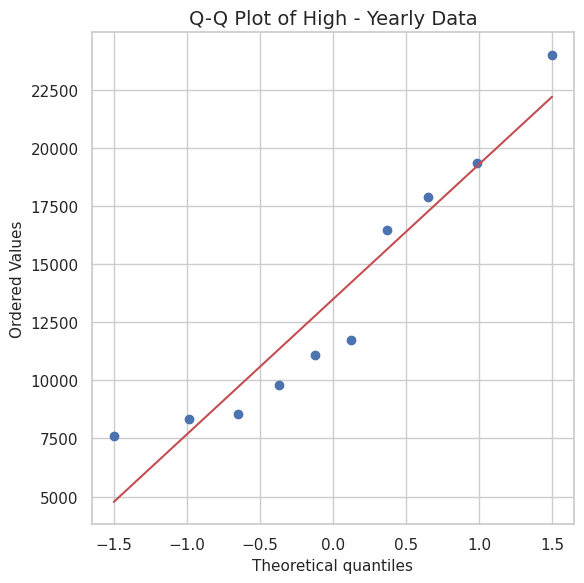

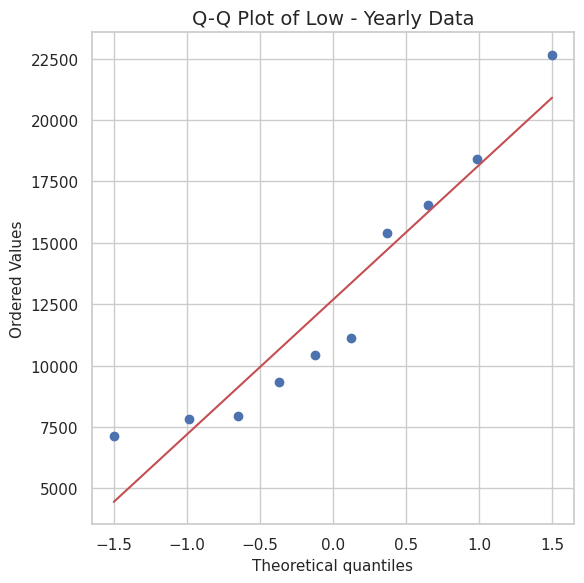

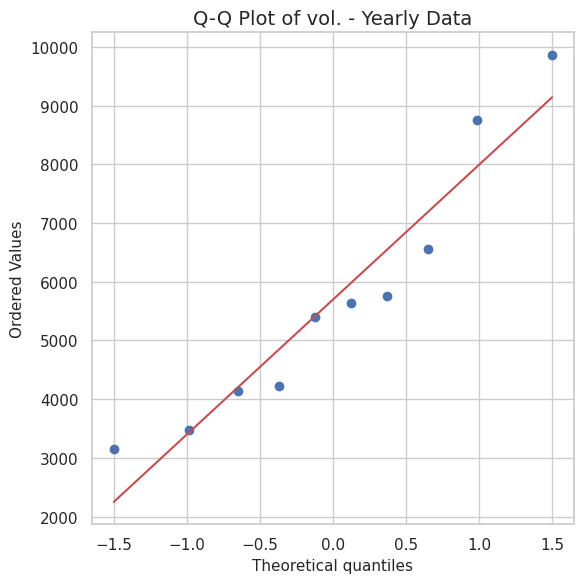

In [44]:
# ============================================================
# Q-Q PLOTS
# ============================================================

for name, df in clean_datasets.items():

    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns

    for col in numeric_columns:

        plt.figure(figsize=(6, 6))

        stats.probplot(
            df[col].dropna(),
            dist="norm",
            plot=plt
        )

        plt.title(
            f"Q-Q Plot of {col} - {name} Data"
        )

        plt.tight_layout()
        plt.show()

In [45]:
# ============================================================
# TWO-WAY ANOVA
# ============================================================
#
# Factors:
# Year
# OHLC variable
#
# Dependent variable:
# Value
#
# Model:
# Value ~ Year + OHLC + Year:OHLC
# ============================================================


# Use original daily data for ANOVA
# because removing genuine extreme market observations
# may alter the structure of the yearly data.

anova_data = datasets["Daily"].copy()


# Extract Year

anova_data["Year"] = (
    anova_data["Date"]
    .dt.year
)


# Relevant OHLC variables

ohlc_columns = [
    "Price",
    "Open",
    "High",
    "Low"
]


# Convert to long format

anova_long = anova_data.melt(
    id_vars=["Year"],
    value_vars=ohlc_columns,
    var_name="OHLC",
    value_name="Value"
)


anova_long = anova_long.dropna()


print("\nReshaped ANOVA data:")
print(anova_long.head())


Reshaped ANOVA data:
   Year   OHLC    Value
0  2014  Price  6301.65
1  2014  Price  6221.15
2  2014  Price  6211.15
3  2014  Price  6191.45
4  2014  Price  6162.25


In [46]:
# ============================================================
# TWO-WAY ANOVA MODEL
# ============================================================

anova_model = ols(
    "Value ~ C(Year) + C(OHLC) + C(Year):C(OHLC)",
    data=anova_long
).fit()


anova_results = anova_lm(
    anova_model,
    typ=2
)


# Add Mean Square

anova_results["MS"] = (
    anova_results["sum_sq"]
    /
    anova_results["df"]
)


# Calculate F-critical value

alpha = 0.05

residual_df = anova_results.loc[
    "Residual",
    "df"
]


f_critical = []


for df_value in anova_results["df"]:

    if pd.isna(df_value):

        f_critical.append(np.nan)

    else:

        f_critical.append(
            f.ppf(
                1 - alpha,
                df_value,
                residual_df
            )
        )


anova_results["F crit"] = f_critical


anova_table = anova_results.rename(
    columns={
        "sum_sq": "SS",
        "PR(>F)": "P-value"
    }
)


anova_table = anova_table[
    [
        "SS",
        "df",
        "MS",
        "F",
        "P-value",
        "F crit"
    ]
]


print("\n" + "=" * 80)
print("TWO-WAY ANOVA RESULTS")
print("=" * 80)

print(anova_table.round(6))


TWO-WAY ANOVA RESULTS
                           SS       df            MS             F  P-value  \
C(Year)          2.580533e+11     10.0  2.580533e+10  31632.792008      0.0   
C(OHLC)          2.639729e+07      3.0  8.799095e+06     10.786141      0.0   
C(Year):C(OHLC)  3.972616e+06     30.0  1.324205e+05      0.162324      1.0   
Residual         8.767981e+09  10748.0  8.157779e+05           NaN      NaN   

                   F crit  
C(Year)          1.831582  
C(OHLC)          2.605735  
C(Year):C(OHLC)  1.460170  
Residual         1.032242  


In [47]:
# ============================================================
# ANOVA HYPOTHESIS INTERPRETATION
# ============================================================

print("\n" + "=" * 80)
print("ANOVA HYPOTHESIS TESTING")
print("=" * 80)


print("""
Factor 1: Year

H0: The mean values are equal across years.
H1: At least one year's mean value is significantly different.


Factor 2: OHLC

H0: The mean values of Price, Open, High and Low are equal.
H1: At least one OHLC variable has a significantly different mean.


Interaction: Year × OHLC

H0: There is no significant interaction between Year and OHLC.
H1: There is a significant interaction between Year and OHLC.

Decision rule:
If p-value < 0.05 → Reject H0.
If p-value >= 0.05 → Fail to reject H0.
""")


# Automatic interpretation

for factor in [
    "C(Year)",
    "C(OHLC)",
    "C(Year):C(OHLC)"
]:

    p_value = anova_table.loc[
        factor,
        "P-value"
    ]

    if p_value < 0.05:

        print(
            f"{factor}: Significant "
            f"(p = {p_value:.6f})"
        )

    else:

        print(
            f"{factor}: Not Significant "
            f"(p = {p_value:.6f})"
        )


ANOVA HYPOTHESIS TESTING

Factor 1: Year

H0: The mean values are equal across years.
H1: At least one year's mean value is significantly different.


Factor 2: OHLC

H0: The mean values of Price, Open, High and Low are equal.
H1: At least one OHLC variable has a significantly different mean.


Interaction: Year × OHLC

H0: There is no significant interaction between Year and OHLC.
H1: There is a significant interaction between Year and OHLC.

Decision rule:
If p-value < 0.05 → Reject H0.
If p-value >= 0.05 → Fail to reject H0.

C(Year): Significant (p = 0.000000)
C(OHLC): Significant (p = 0.000000)
C(Year):C(OHLC): Not Significant (p = 1.000000)


In [48]:
# ============================================================
# STATIONARITY TESTS - ADF AND KPSS
# ============================================================

def stationarity_tests(df, dataset_name):

    results = []

    if "Date" not in df.columns:

        return pd.DataFrame()

    df = df.sort_values("Date")

    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns


    for col in numeric_columns:

        series = (
            df.set_index("Date")[col]
            .dropna()
        )


        # ----------------------------------------------------
        # ADF Test
        # ----------------------------------------------------

        try:

            adf_stat, adf_p, _, _, adf_crit, _ = (
                adfuller(
                    series,
                    autolag="AIC"
                )
            )

            adf_conclusion = (
                "Stationary"
                if adf_p < 0.05
                else "Non-Stationary"
            )

        except Exception:

            adf_stat = np.nan
            adf_p = np.nan
            adf_crit = {}

            adf_conclusion = "Test Failed"


        # ----------------------------------------------------
        # KPSS Test
        # ----------------------------------------------------

        try:

            kpss_stat, kpss_p, _, kpss_crit = (
                kpss(
                    series,
                    regression="c",
                    nlags="auto"
                )
            )

            kpss_conclusion = (
                "Non-Stationary"
                if kpss_p < 0.05
                else "Stationary"
            )

        except Exception:

            kpss_stat = np.nan
            kpss_p = np.nan
            kpss_crit = {}

            kpss_conclusion = "Test Failed"


        results.append({

            "Dataset": dataset_name,

            "Variable": col,

            "ADF Statistic": adf_stat,

            "ADF p-value": adf_p,

            "ADF Conclusion": adf_conclusion,

            "KPSS Statistic": kpss_stat,

            "KPSS p-value": kpss_p,

            "KPSS Conclusion": kpss_conclusion
        })


    return pd.DataFrame(results)


stationarity_results = []


for name, df in clean_datasets.items():

    result = stationarity_tests(
        df,
        name
    )

    stationarity_results.append(result)


stationarity_table = pd.concat(
    stationarity_results,
    ignore_index=True
)


print("\n" + "=" * 80)
print("ADF AND KPSS STATIONARITY RESULTS")
print("=" * 80)

print(
    stationarity_table.round(6)
)


ADF AND KPSS STATIONARITY RESULTS
    Dataset Variable  ADF Statistic  ADF p-value  ADF Conclusion  \
0     Daily    Price       0.523130     0.985559  Non-Stationary   
1     Daily     Open       0.520297     0.985477  Non-Stationary   
2     Daily     High       0.675125     0.989328  Non-Stationary   
3     Daily      Low       0.478529     0.984206  Non-Stationary   
4     Daily     vol.      -2.617212     0.089492  Non-Stationary   
5   Monthly    Price       1.018881     0.994461  Non-Stationary   
6   Monthly     Open       0.938446     0.993572  Non-Stationary   
7   Monthly     High       0.626519     0.988251  Non-Stationary   
8   Monthly      Low       0.423579     0.982356  Non-Stationary   
9   Monthly     vol.      -1.728645     0.416417  Non-Stationary   
10   Yearly    Price      -1.382777     0.590505  Non-Stationary   
11   Yearly     Open      -0.835740     0.808398  Non-Stationary   
12   Yearly     High      -1.138191     0.699604  Non-Stationary   
13   Yearly  

In [49]:
# ============================================================
# STATIONARITY INTERPRETATION
# ============================================================

print("""
Stationarity interpretation:

ADF Test:
H0 = Series contains a unit root / is non-stationary.
p-value < 0.05 → Reject H0 → Stationary.

KPSS Test:
H0 = Series is stationary.
p-value < 0.05 → Reject H0 → Non-stationary.

Using both tests provides stronger evidence because
their null hypotheses are opposite.
""")


Stationarity interpretation:

ADF Test:
H0 = Series contains a unit root / is non-stationary.
p-value < 0.05 → Reject H0 → Stationary.

KPSS Test:
H0 = Series is stationary.
p-value < 0.05 → Reject H0 → Non-stationary.

Using both tests provides stronger evidence because
their null hypotheses are opposite.



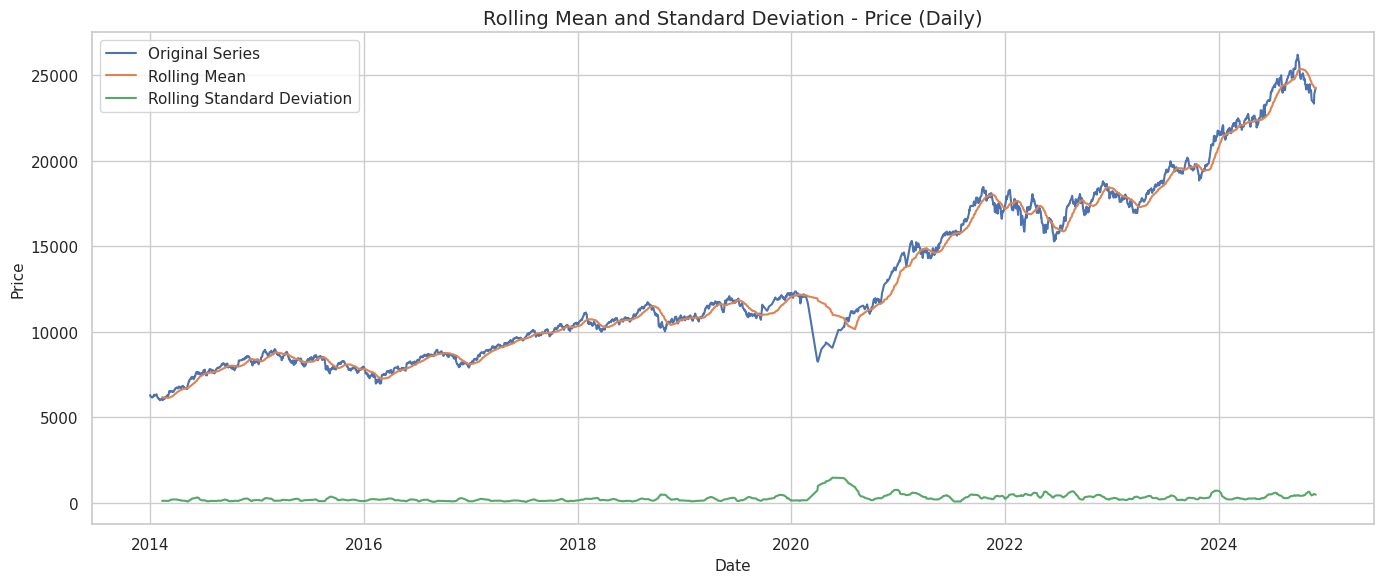

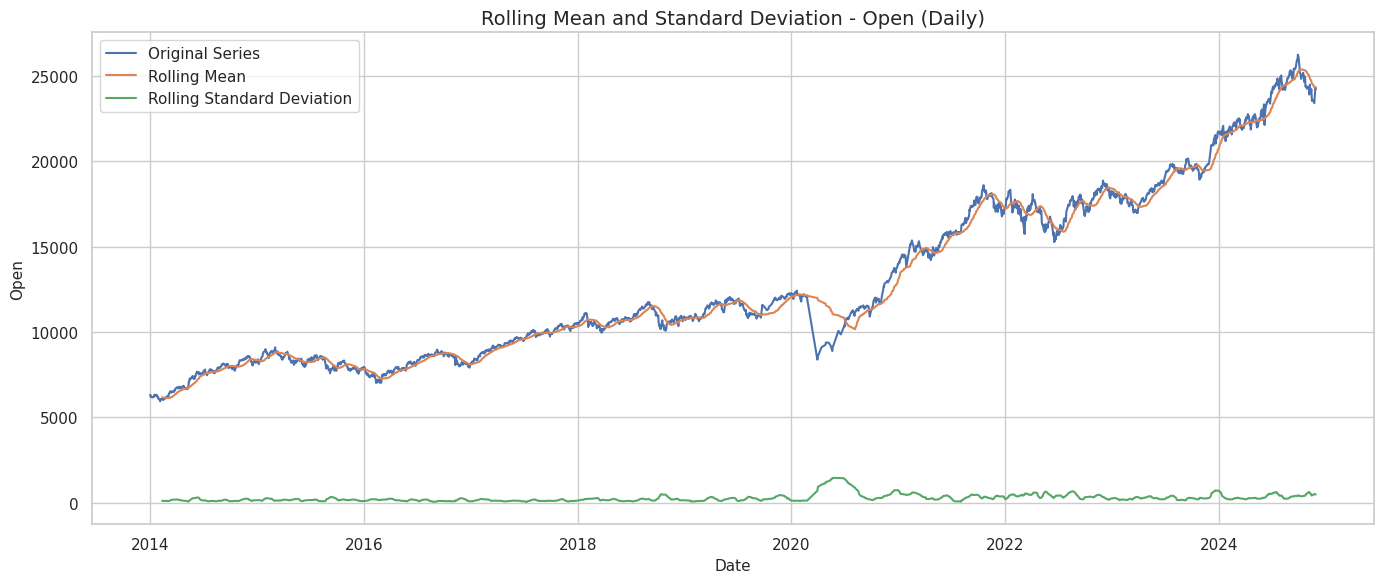

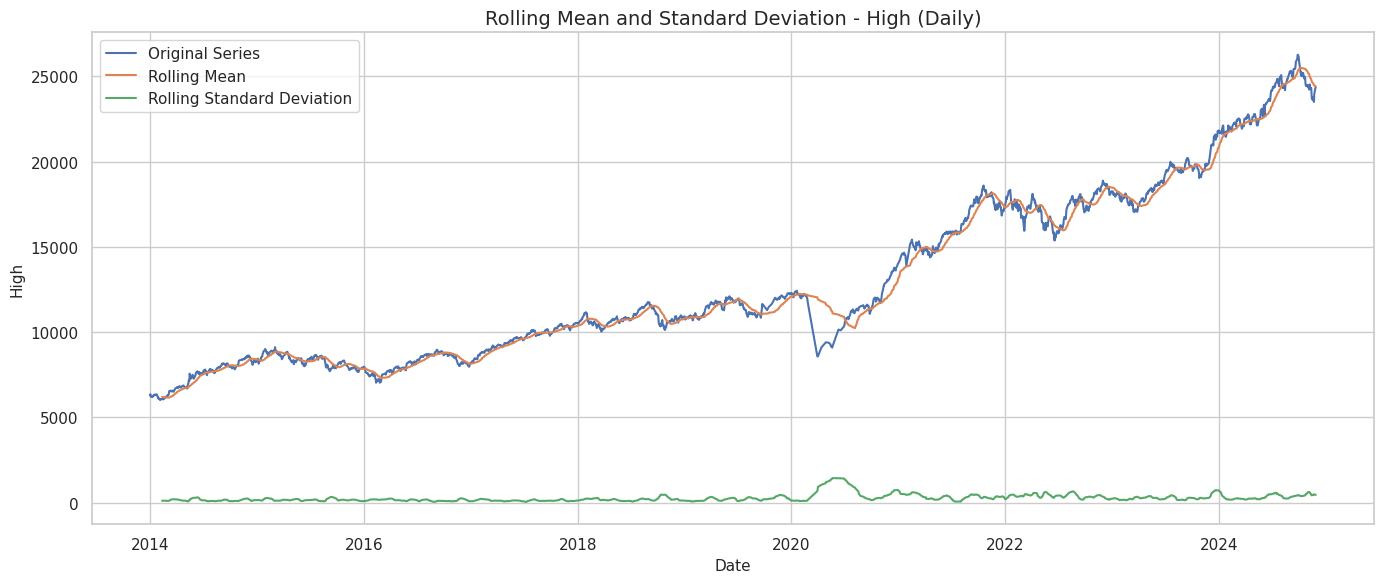

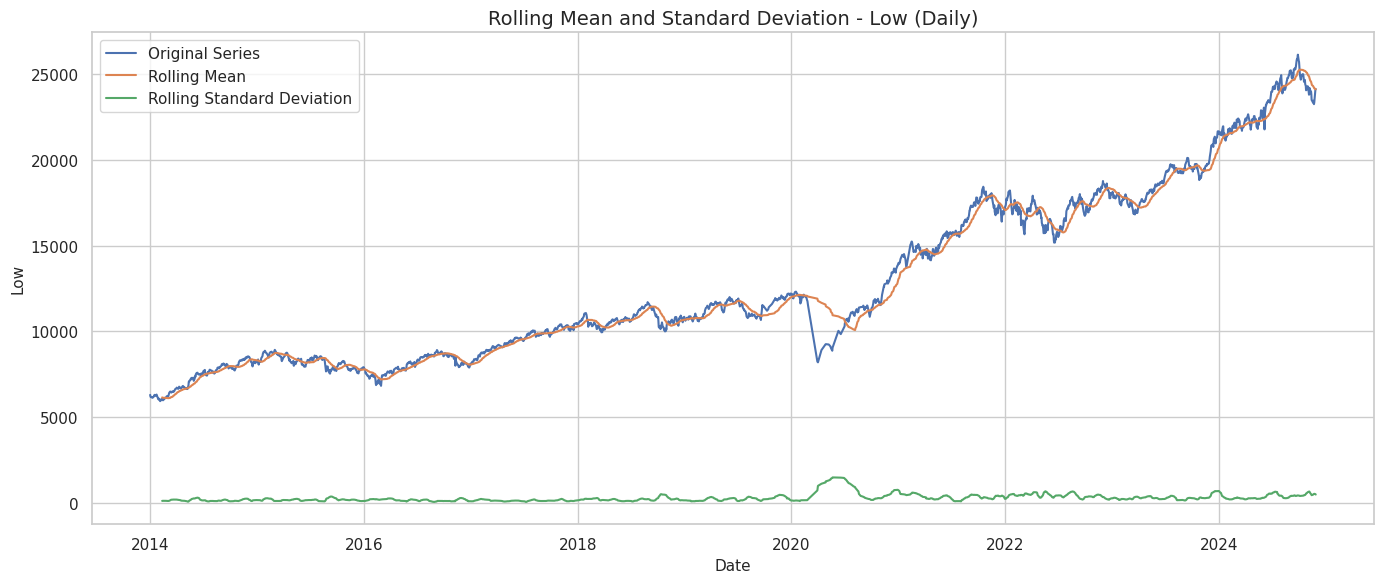

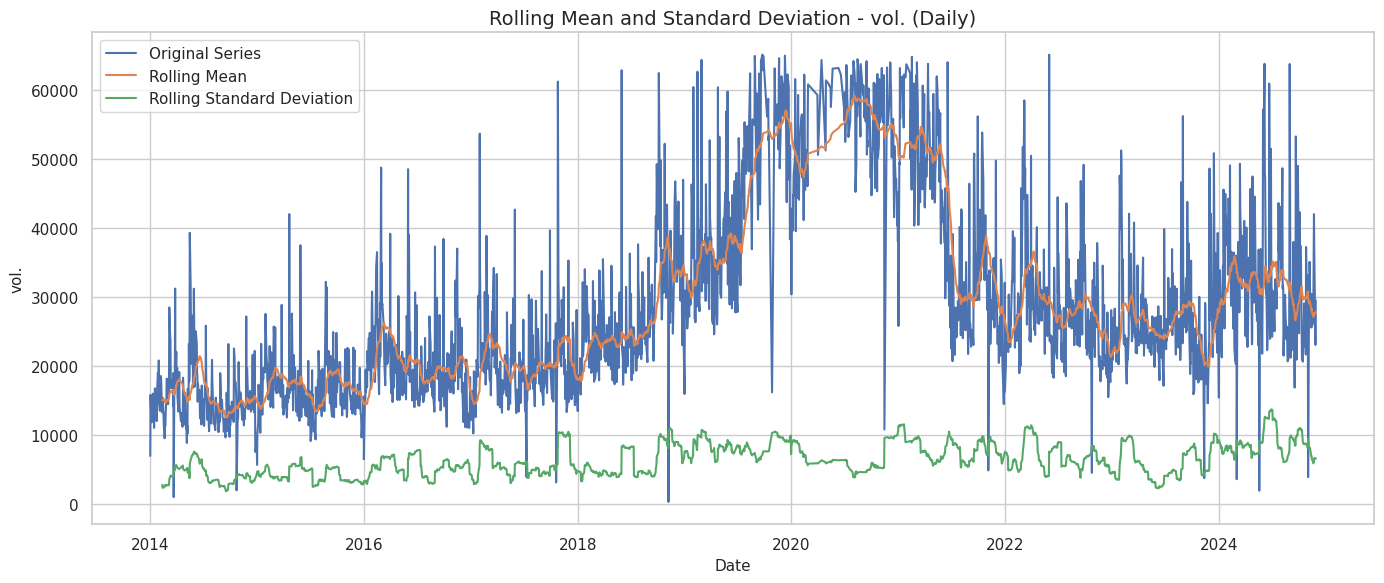

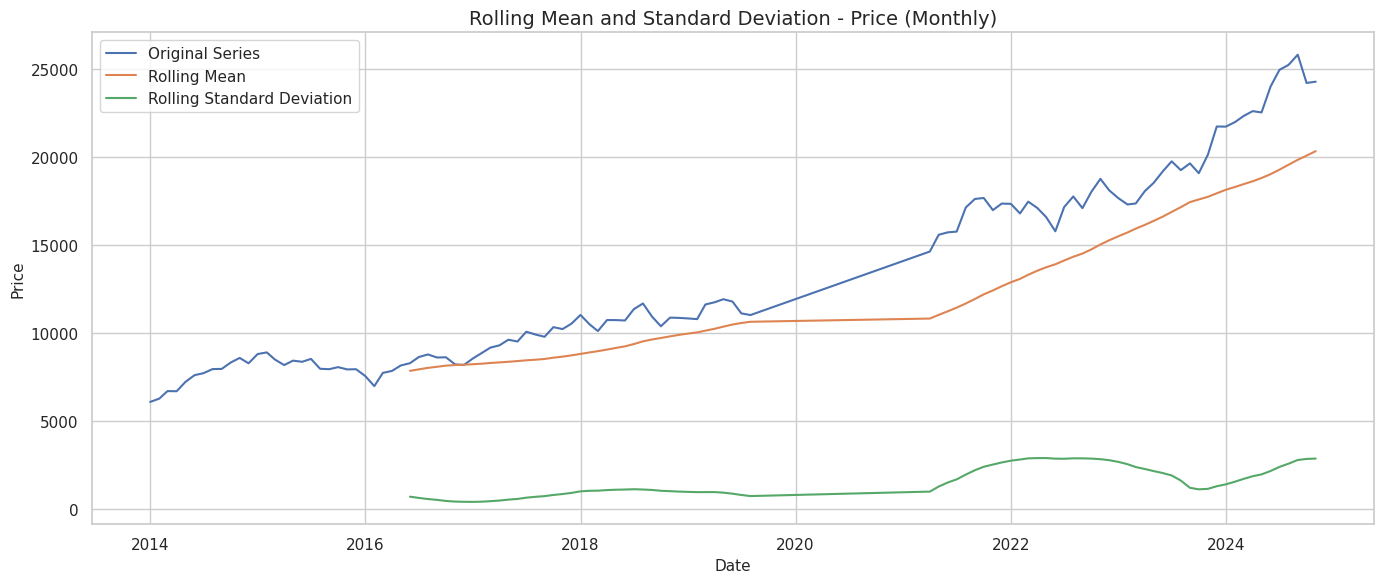

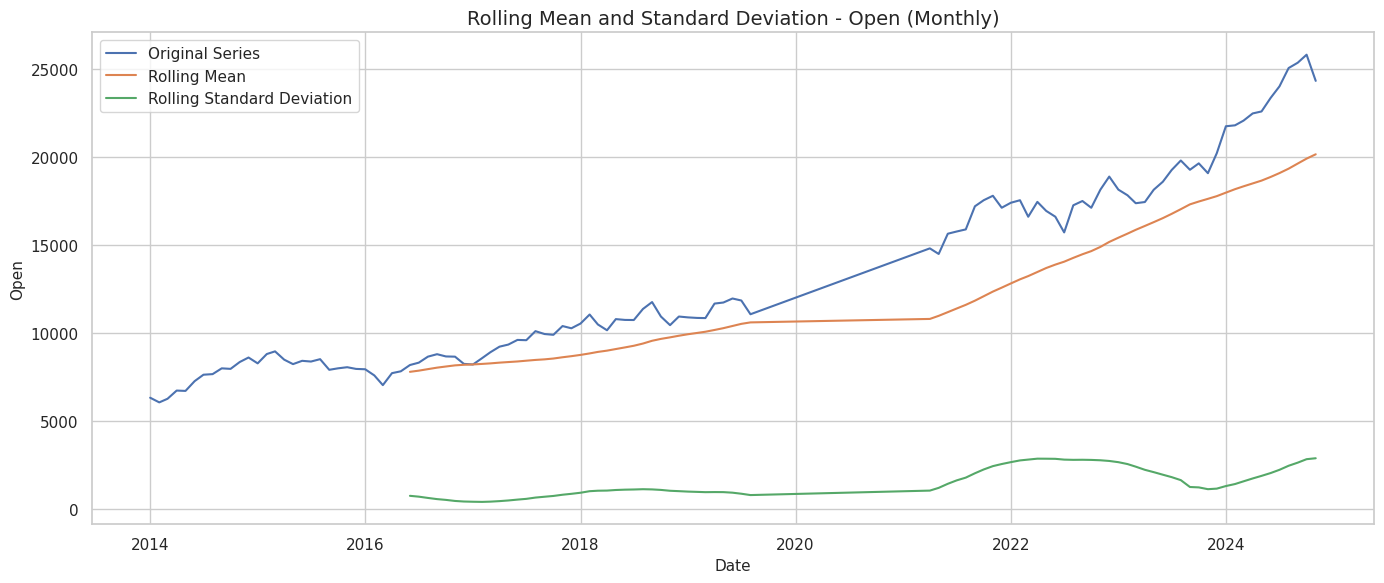

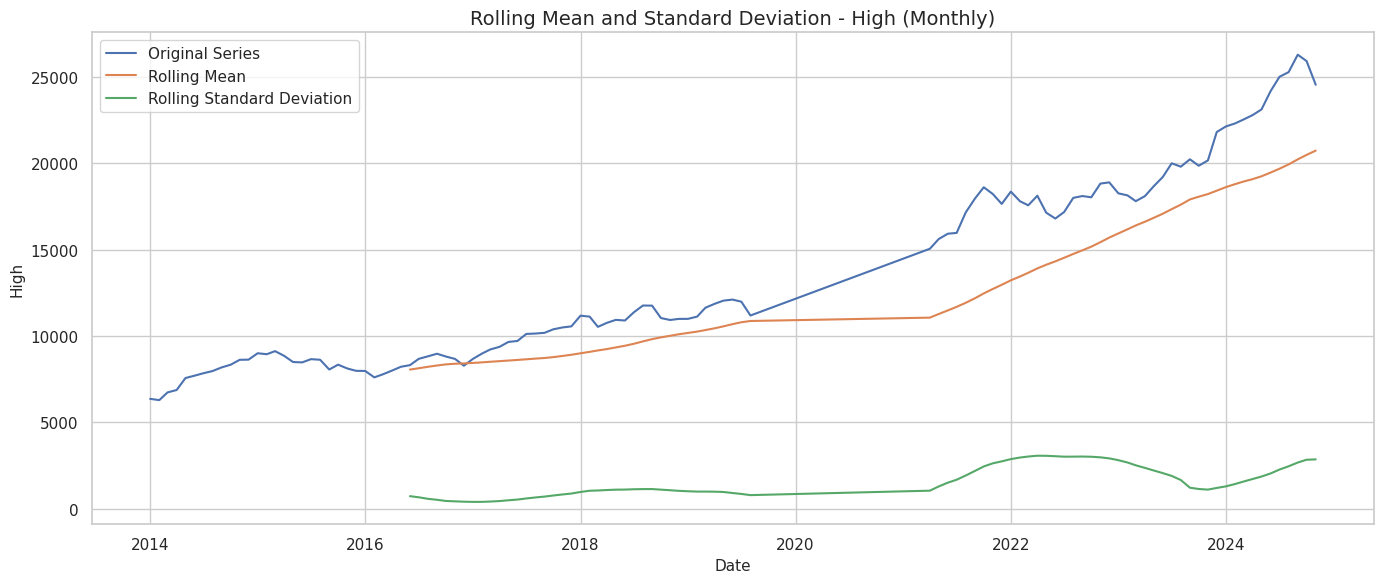

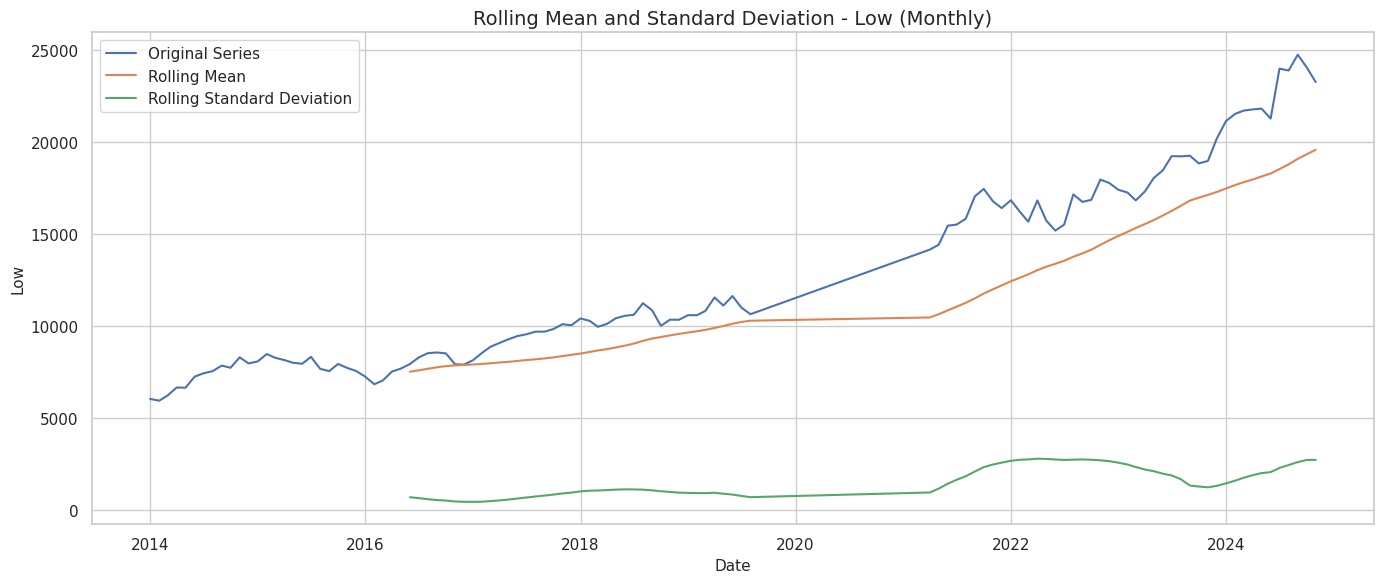

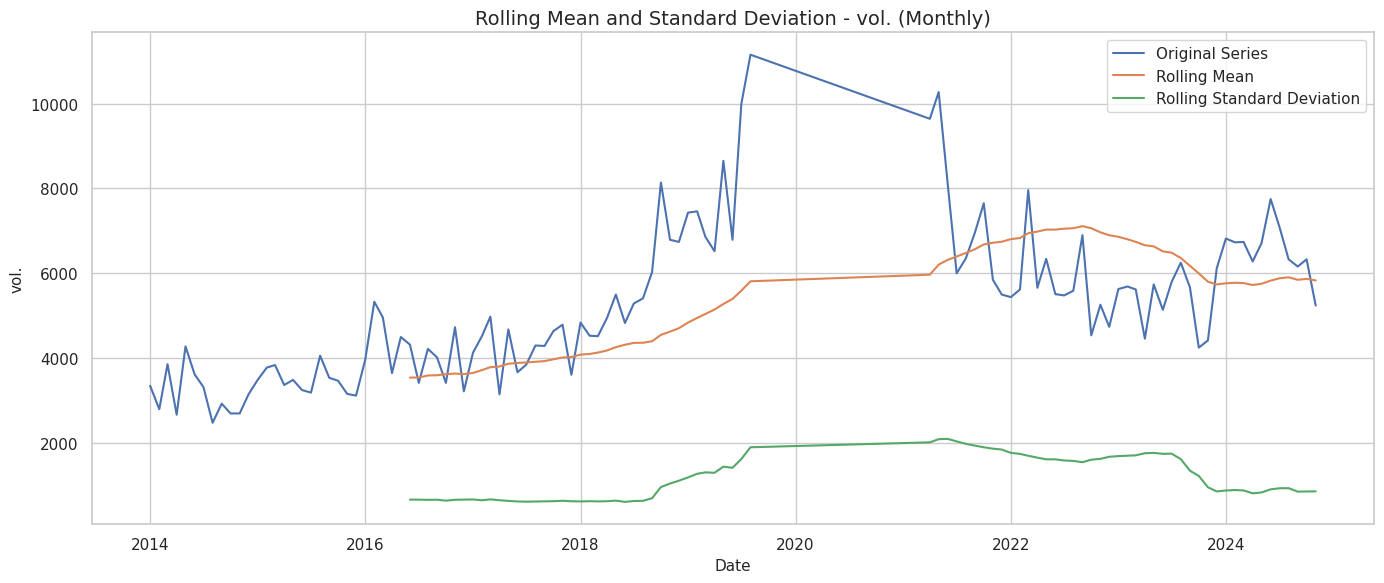

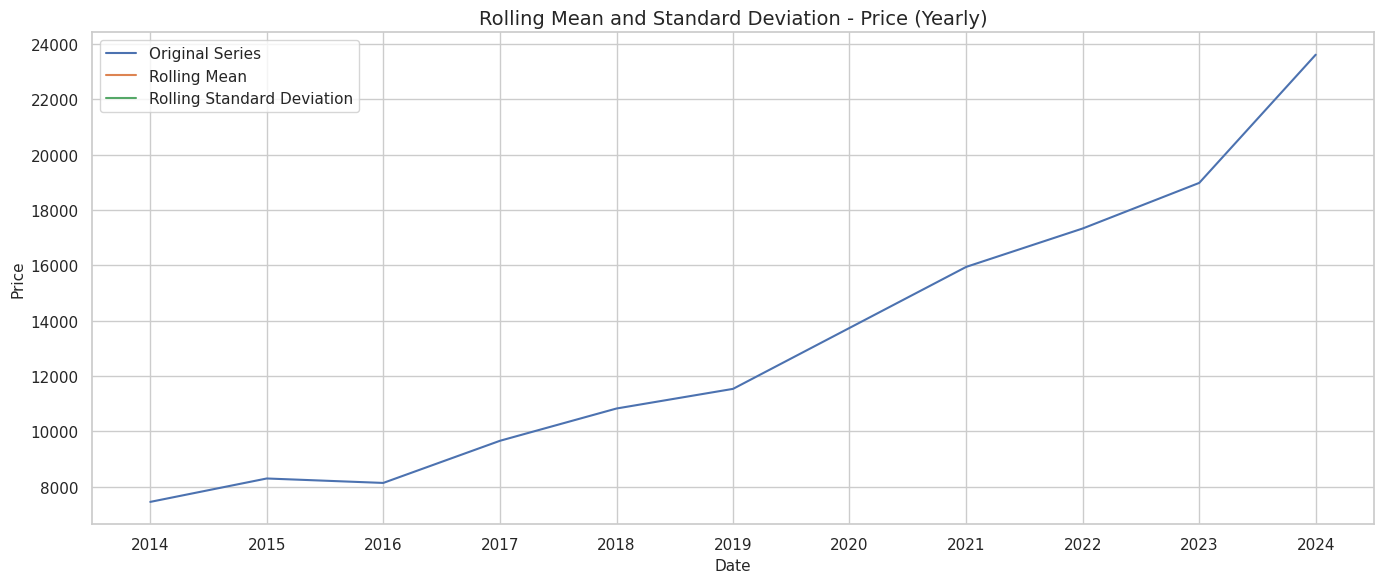

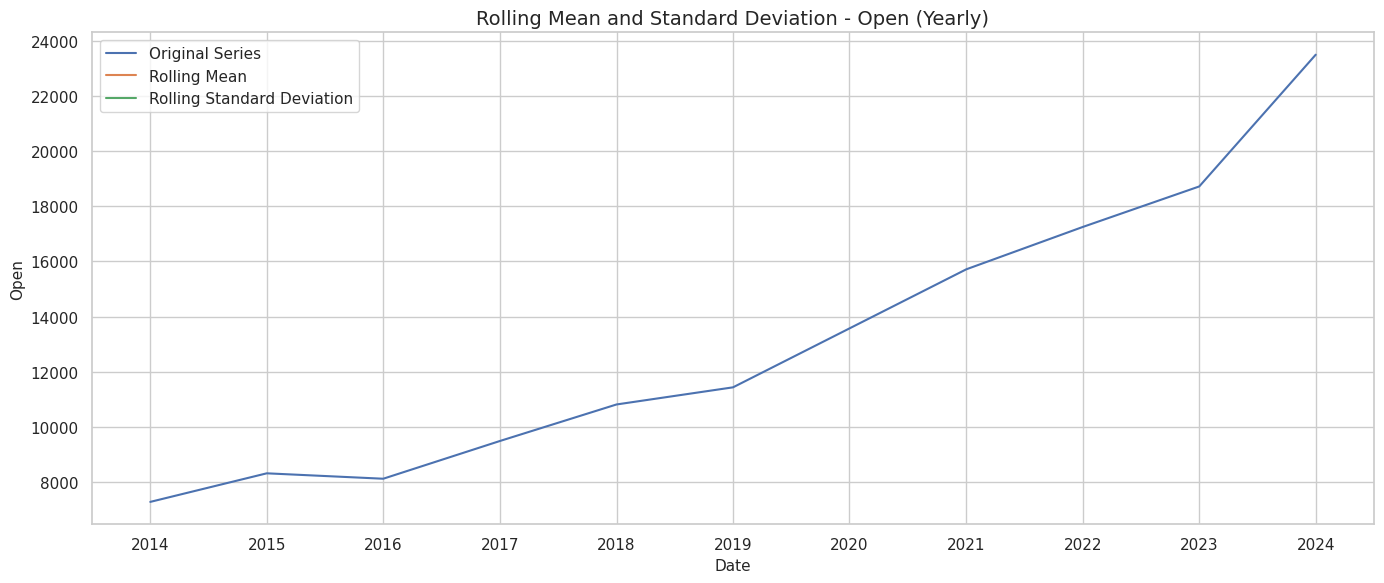

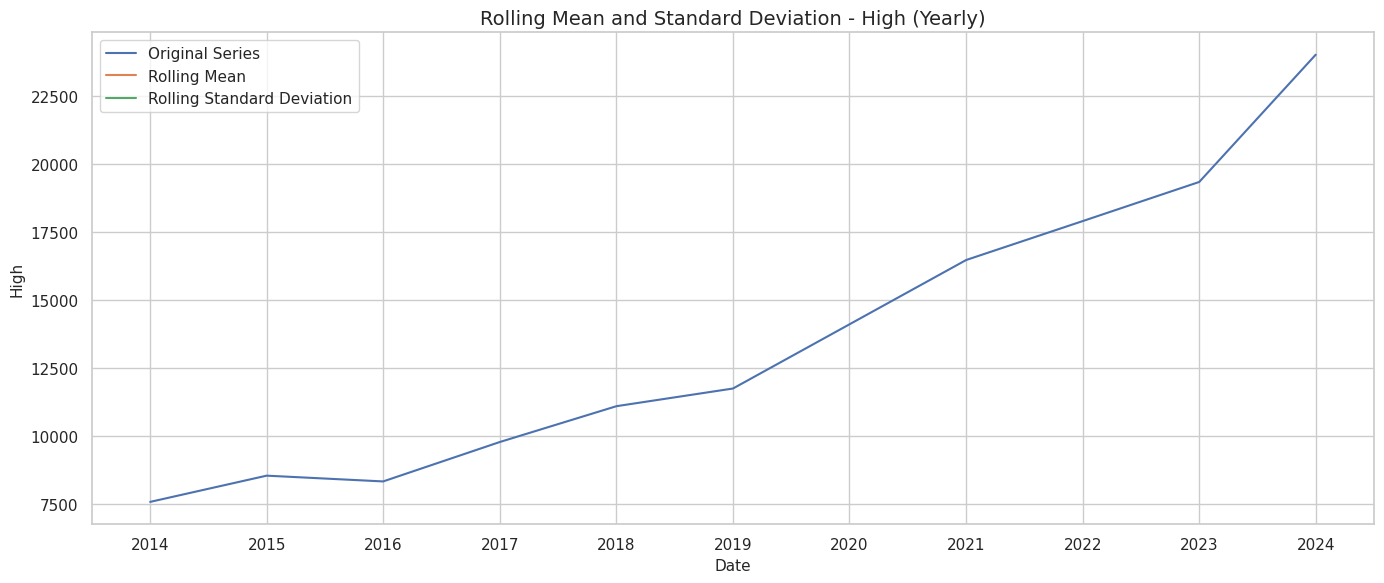

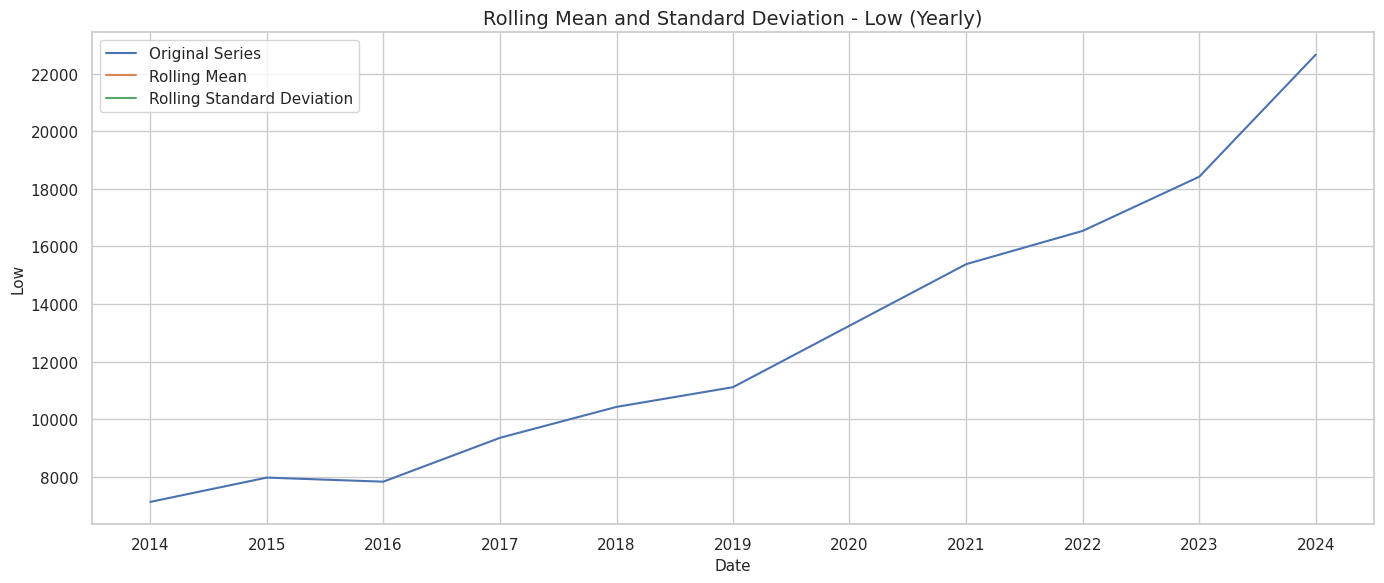

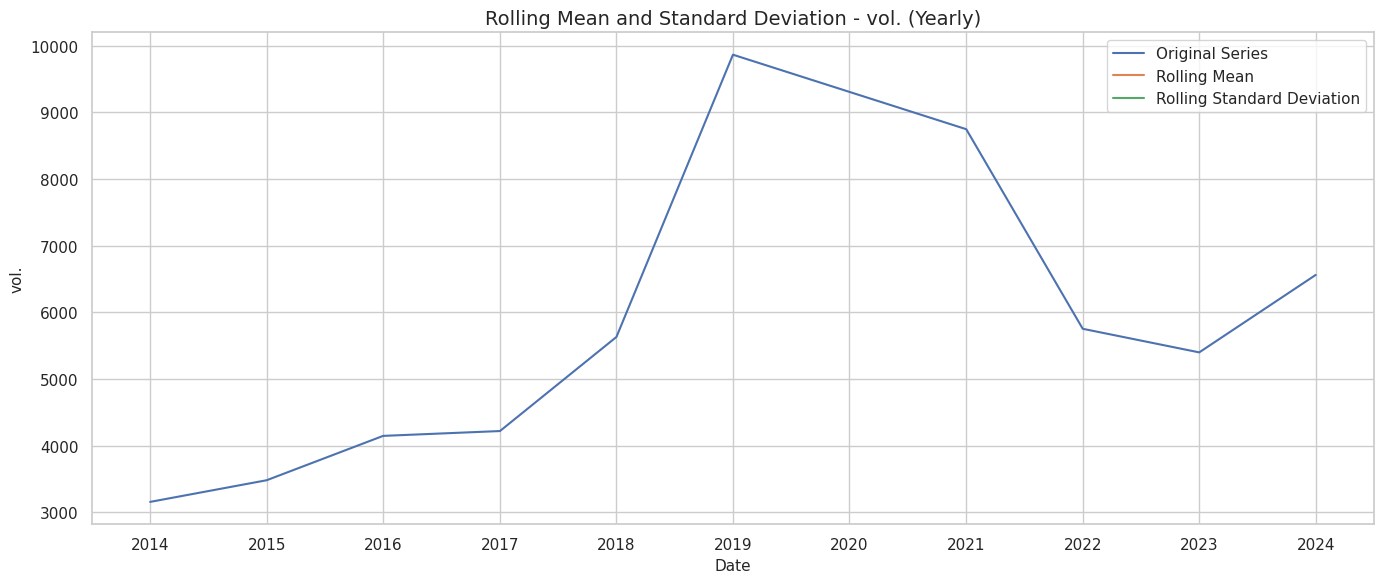

In [50]:
# ============================================================
# ROLLING MEAN AND STANDARD DEVIATION
# ============================================================

def rolling_statistics(df, dataset_name):

    if "Date" not in df.columns:
        return

    df = df.sort_values("Date")

    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns


    for col in numeric_columns:

        series = df.set_index(
            "Date"
        )[col].dropna()


        window = 30

        rolling_mean = (
            series
            .rolling(window)
            .mean()
        )

        rolling_std = (
            series
            .rolling(window)
            .std()
        )


        plt.figure(figsize=(14, 6))

        plt.plot(
            series,
            label="Original Series"
        )

        plt.plot(
            rolling_mean,
            label="Rolling Mean"
        )

        plt.plot(
            rolling_std,
            label="Rolling Standard Deviation"
        )

        plt.title(
            f"Rolling Mean and Standard Deviation - "
            f"{col} ({dataset_name})"
        )

        plt.xlabel("Date")
        plt.ylabel(col)

        plt.legend()

        plt.tight_layout()
        plt.show()


for name, df in clean_datasets.items():

    rolling_statistics(
        df,
        name
    )

In [51]:
# ============================================================
# SAVE ALL RESULTS TO EXCEL
# ============================================================

output_file = "Nifty50_Complete_Analysis_Results.xlsx"


with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # Missing values
    missing_table.to_excel(
        writer,
        sheet_name="Missing Values",
        index=False
    )

    # Outlier comparison
    outlier_comparison.to_excel(
        writer,
        sheet_name="Outlier Comparison",
        index=False
    )

    # Descriptive statistics
    for name, result in descriptive_results.items():

        sheet_name = (
            f"{name} Descriptive"
        )

        result.to_excel(
            writer,
            sheet_name=sheet_name
        )


    # Comparative analysis
    comparison_table.to_excel(
        writer,
        sheet_name="Comparative Analysis",
        index=False
    )


    # Normality
    normality_table.to_excel(
        writer,
        sheet_name="Normality",
        index=False
    )


    # ANOVA
    anova_table.to_excel(
        writer,
        sheet_name="Two Way ANOVA"
    )


    # Stationarity
    stationarity_table.to_excel(
        writer,
        sheet_name="Stationarity",
        index=False
    )


    # Correlations
    for name, corr in correlation_results.items():

        corr.to_excel(
            writer,
            sheet_name=f"{name} Correlation"
        )


print(
    f"\nAll statistical results saved to: {output_file}"
)


All statistical results saved to: Nifty50_Complete_Analysis_Results.xlsx


In [52]:
# ============================================================
# FINAL ANALYSIS SUMMARY
# ============================================================

print("\n")
print("=" * 90)
print("NIFTY 50 COMPLETE ANALYSIS")
print("=" * 90)

print("""
Analysis successfully completed:

1. Data Loading
2. Dataset Structure and Dimensions
3. Data Type Examination
4. Missing Value Analysis
5. Missing Value Treatment
6. Volume Scaling
7. Date Conversion and Sorting
8. Outlier Detection using IQR
9. Outlier Visualization
10. IQR-based Sensitivity Dataset
11. Detailed Descriptive Statistics
12. Distribution Analysis
13. Skewness and Kurtosis
14. Correlation Analysis
15. Correlation Heatmaps
16. Pairwise Relationship Analysis
17. Daily vs Monthly vs Yearly Comparison
18. Mean Comparison
19. Standard Deviation Comparison
20. Coefficient of Variation
21. Moving Average Trend Analysis
22. Linear Trend Analysis
23. Normality Tests
24. Q-Q Plots
25. Two-Way ANOVA
26. ANOVA Hypothesis Testing
27. ADF Stationarity Test
28. KPSS Stationarity Test
29. Rolling Mean and Standard Deviation
30. Excel Export of Statistical Results

The analysis pipeline is complete.
""")



NIFTY 50 COMPLETE ANALYSIS

Analysis successfully completed:

1. Data Loading
2. Dataset Structure and Dimensions
3. Data Type Examination
4. Missing Value Analysis
5. Missing Value Treatment
6. Volume Scaling
7. Date Conversion and Sorting
8. Outlier Detection using IQR
9. Outlier Visualization
10. IQR-based Sensitivity Dataset
11. Detailed Descriptive Statistics
12. Distribution Analysis
13. Skewness and Kurtosis
14. Correlation Analysis
15. Correlation Heatmaps
16. Pairwise Relationship Analysis
17. Daily vs Monthly vs Yearly Comparison
18. Mean Comparison
19. Standard Deviation Comparison
20. Coefficient of Variation
21. Moving Average Trend Analysis
22. Linear Trend Analysis
23. Normality Tests
24. Q-Q Plots
25. Two-Way ANOVA
26. ANOVA Hypothesis Testing
27. ADF Stationarity Test
28. KPSS Stationarity Test
29. Rolling Mean and Standard Deviation
30. Excel Export of Statistical Results

The analysis pipeline is complete.

